# Setup

## Libraries Loading

In [35]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown


# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
# make_scorer source: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html
from sklearn.metrics import confusion_matrix, make_scorer, roc_auc_score,  ConfusionMatrixDisplay, classification_report, get_scorer_names
from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve, GridSearchCV, train_test_split
from sklearn.feature_selection import RFE,  SequentialFeatureSelector
# clone source: https://scikit-learn.org/stable/modules/generated/sklearn.base.clone.html
from sklearn.base import clone
from sklearn.preprocessing import FunctionTransformer

# Statistics
from scipy import stats
from sklearn.preprocessing import StandardScaler

# Imblearn Oversampling
# imblearn source: https://imbalanced-learn.org/stable/over_sampling.html
from imblearn.over_sampling import SMOTENC, SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE
from imblearn.pipeline import Pipeline

# Utilitary
import src.utils.utils as ut
import src.utils.model_prep_eval as mod_prep

## Data Loading

### Wines Data

In [36]:
# Loads data from source and sets wine_id
wine_df = pd.read_csv(ut.get_project_file_path("src", "data", "transformed", "wines_clean.csv"))
wine_df = wine_df.reset_index(drop=False)
wine_df = wine_df.rename(columns={"index": "wine_id"})

### Users Data

In [37]:
# Loads and concatenates user data
users_data = pd.read_pickle(ut.get_project_file_path("src", "data", "synthetic", "simulation_13.pkl"))
users_data = users_data.dropna()
users_data.head()

,event_timestamp,user_id,wine_id,user_input,liked,prob_like
0,2022-08-27,0,1233,"{'meal': 'Chucrut con Salchichas', 'main_pairi...",1,0.834773
1,2022-09-23,0,1020,"{'meal': 'Locro', 'main_pairing': 'beef', 'pai...",0,0.466778
2,2022-10-27,0,1629,"{'meal': 'Asado', 'main_pairing': 'beef', 'pai...",1,0.856777
3,2022-11-27,0,615,"{'meal': 'Tabla de Quesos y Embutidos', 'main_...",0,0.471666
4,2022-12-20,0,771,"{'meal': 'Tarta de Vegetales y Queso', 'main_p...",0,0.415275


## Data Prep

### Joining Data

In [38]:
# Agrega la información de los usuarios al df de vinos
joined_data = pd.merge(users_data, wine_df, how="inner", on="wine_id")
joined_data.shape

(13198, 124)

### ETL

In [39]:
def taste_dist_to_optimal(x, min, max):
    if min <= x <= max:
        return 0
    elif x > max:
        return x - max
    else:
        return x - min

def price_dist_to_optimal(x, min, max, center):
    if (max == 2000):
        # Sin precio máximo: el punto óptimo es el mínimo del rango
        return x - min
    else:
        # Con precio máximo: el punto óptimo es el centro del rango
        return x - center
    

In [40]:
# Agrega si el vino tenia match con el main pairing del user
recommend_df = joined_data.copy()
recommend_df["user_main_pairing"] = recommend_df["user_input"].apply(lambda x: x["main_pairing"])
recommend_df["has_user_main_pairing"] = recommend_df.apply(lambda row: 1 if row[row["user_main_pairing"]]==1 else 0, axis=1)

# Agrega los límites inferiores y superiores de sabor según la decisión del usuario
taste_list = ["body", "tannins", "sweetness", "acidity"]
for taste in taste_list:
    recommend_df["user_" + taste + "_min"] = recommend_df["user_input"].apply(lambda x: x["tastes"][taste][0])
    recommend_df["user_" + taste + "_max"] = recommend_df["user_input"].apply(lambda x: x["tastes"][taste][1])
    recommend_df["user_" + taste + "_center"] = (recommend_df["user_" + taste + "_max"] + recommend_df["user_" + taste + "_min"])/2
    recommend_df["user_" + taste + "_range"] = (recommend_df["user_" + taste + "_max"] - recommend_df["user_" + taste + "_min"])
    recommend_df["user_" + taste + "_diff"] = recommend_df.apply(
        lambda row: taste_dist_to_optimal(
            x=row[taste],
            min=row["user_" + taste + "_min"],
            max=row["user_" + taste + "_max"]
        ),
        axis=1
    )

# Agrega los precios máximos y mínimos, rango y distancia del precio al óptimo
recommend_df["user_price_min"] = recommend_df["user_input"].apply(lambda x: x["precio_min"])
recommend_df["user_price_max"] = recommend_df["user_input"].apply(lambda x: x["precio_max"])
#recommend_df["user_no_price_max"] = pd.isna(recommend_df["user_price_max"]).astype(int)
recommend_df["user_price_max"] = recommend_df["user_price_max"].fillna(2000)
recommend_df["user_price_range"] = recommend_df["user_price_max"] - recommend_df["user_price_min"]
recommend_df["user_price_center"] = (recommend_df["user_price_max"] + recommend_df["user_price_min"])/2
recommend_df["user_price_diff"] = recommend_df.apply(
    lambda row: price_dist_to_optimal(
        x=row["price"],
        min=row["user_price_min"],
        max=row["user_price_max"],
        center=row["user_price_center"]
    ),
    axis=1
)

pd.set_option("display.max_columns", None)
recommend_df.head()
    
    # TODO:
        # OK - 1. terminar de hacer feature engineering para obtener distancias. -> Me quedé en como poner la distancia al precio (rango?)
        # OK - 2. Estandarizar datos y entrenar modelo KNN en pipeline (ver si hace sentido over/under sampling)
        # 3. Explorar la validación por grupos (GroupKFold)
        # 4. Entrenar y testear modelo
        # 5. Si no rinde bien, seguir con XGBoost y Neural Networks

#recommend_df.shape

,event_timestamp,user_id,wine_id,user_input,liked,prob_like,wine_link,name,year,winery,rating,rating_qty,price,body,tannins,sweetness,acidity,style,alcohol,image,ageing,black fruit,citrus,dried fruit,earthy,floral,oaky,red fruit,spices,tree fruit,tropical,vegetal,yeasty,any junk food will do,aperitif,appetizers and snacks,beef,blue cheese,cured meat,"game (deer, venison)",goat's milk cheese,lamb,lean fish,mature and hard cheese,mild and soft cheese,mushrooms,pasta,pork,poultry,"rich fish (salmon, tuna etc)",shellfish,spicy food,veal,vegetarian,Albariño,Barbera,Bonarda,Béquignol Noir,Cabernet Franc,Cabernet Sauvignon,Cereza,Chardonnay,Chenin Blanc,Criolla Grande,Garnacha,Gewürztraminer,Grenache,Grüner Veltliner,Malbec,Malvasia,Marsanne,Mencia,Merlot,Moscatel,Mourvedre,Pais,Pedro Ximenez,Petit Verdot,Pinot Gris,Pinot Noir,Riesling,Roussanne,Sangiovese,Sauvignon Blanc,Shiraz/Syrah,Sémillon,Tannat,Tempranillo,Torrontés,Trousseau,Verdejo,Viognier,Agrelo,Argentina,Brazil,Cafayate Valley,Calchaqui Valley,Campanha,Famatina,Gualtallary,La Consulta,La Rioja,Las Compuertas,Lujan de Cuyo,Lunlunta,Maipu,Mendoza,Paraje Altamira,Patagonia,Pedernal Valley,Perdriel,Rio Grande do Sul,Rio Negro,Salta,San Carlos,San Juan,San Rafael,Serra Gaúcha,Tulum Valley,Tunuyán,Tupungato,Uco Valley,Vale dos Vinhedos,Vista Flores,user_main_pairing,has_user_main_pairing,user_body_min,user_body_max,user_body_center,user_body_range,user_body_diff,user_tannins_min,user_tannins_max,user_tannins_center,user_tannins_range,user_tannins_diff,user_sweetness_min,user_sweetness_max,user_sweetness_center,user_sweetness_range,user_sweetness_diff,user_acidity_min,user_acidity_max,user_acidity_center,user_acidity_range,user_acidity_diff,user_price_min,user_price_max,user_price_range,user_price_center,user_price_diff
0,2022-08-27,0,1233,"{'meal': 'Chucrut con Salchichas', 'main_pairi...",1,0.834773,https://www.vivino.com/el-enemigo-bonarda/w/12...,Bonarda,2016.0,El Enemigo,4.3,3243.0,24.95,0.5392,0.2904,0.2272,0.6372,Argentinian Bonarda,0.1350,https://images.vivino.com/thumbs/uliX_BdfTCaMr...,0.0061,0.2825,0.0130,0.0154,0.1242,0.0239,0.3153,0.1100,0.0820,0.0106,0.0028,0.0065,0.0077,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,pork,1,0.2896,0.519075,0.404338,0.229475,0.020125,0.3931,0.67500,0.534050,0.28190,-0.1027,0.0000,0.1514,0.07570,0.1514,0.0758,0.5147,0.8132,0.66395,0.2985,0.0000,15,46.0,31.0,30.5,-5.55
1,2022-09-23,0,1020,"{'meal': 'Locro', 'main_pairing': 'beef', 'pai...",0,0.466778,https://www.vivino.com/ninety-cellars-lot-23-o...,Lot 23 Old Vine Malbec,2022.0,90+ Cellars,3.5,102.0,10.99,0.6731,0.2431,0.1652,0.3639,Argentinian Mendoza Malbec Red,0.1400,https://images.vivino.com/thumbs/WSbBwS-_SnWJS...,0.0097,0.3973,0.0019,0.0058,0.0988,0.0019,0.2578,0.1492,0.0543,0.0039,0.0039,0.0039,0.0116,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,beef,1,0.3050,0.610000,0.457500,0.305000,0.063100,0.3733,0.50300,0.438150,0.12970,-0.1302,0.1328,0.1827,0.15775,0.0499,0.0000,0.4792,0.8500,0.66460,0.3708,-0.1153,1,15.0,14.0,8.0,2.99
2,2022-10-27,0,1629,"{'meal': 'Asado', 'main_pairing': 'beef', 'pai...",1,0.856777,https://www.vivino.com/pyros-appellation-malbe...,Appellation Malbec,2016.0,Pyros,4.0,1520.0,26.99,0.6178,0.4387,0.3087,0.4437,Argentinian Malbec,0.1400,https://images.vivino.com/thumbs/DmEyYHTtTQqlj...,0.0154,0.3282,0.0000,0.0154,0.1236,0.0309,0.3205,0.1158,0.0425,0.0000,0.0000,0.0000,0.0077,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0

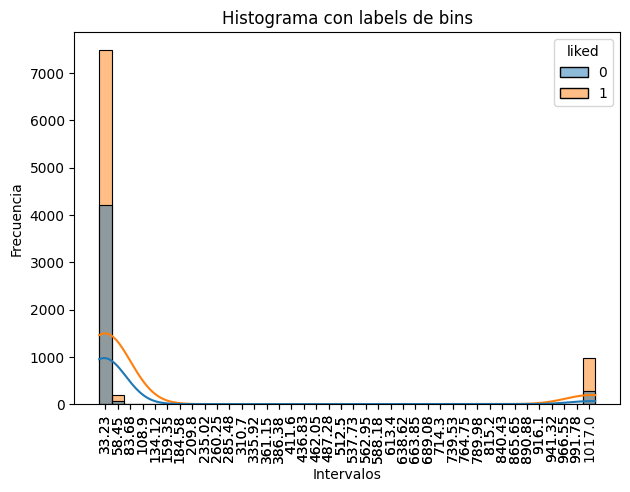

In [41]:
price_subset = recommend_df[[
    "rating", "user_body_diff", "user_tannins_diff", "user_sweetness_diff",
    "user_acidity_diff", "user_price_diff","rating_qty", "has_user_main_pairing",
    "user_price_center",
    "liked"]]
ax = sns.histplot(price_subset, x="user_price_center", hue="liked", kde=True, bins=40)

# Extrae los bins reales usados por seaborn (a través de los patches de matplotlib)
bin_edges = [patch.get_x() for patch in ax.patches]
# Agrega el borde derecho del último bin
bin_edges.append(ax.patches[-1].get_x() + ax.patches[-1].get_width())

# Crea etiquetas
xtick_labels = [f"{round(right,2)}" for right in bin_edges[1:]]
xtick_positions = [(left + right) / 2 for left, right in zip(bin_edges[:-1], bin_edges[1:])]

# Aplica los ticks personalizados
plt.xticks(xtick_positions, xtick_labels, rotation=90)
plt.tight_layout()
plt.xlabel("Intervalos")
plt.ylabel("Frecuencia")
plt.title("Histograma con labels de bins")
plt.show()

### DataFrames For Models Creation

- `model_df`: dataframe base, quitando columnas derivadas de la creación sintética de datos y otras no útiles.

- `model_df_nooh`: dataframe sin columnas one-hot.

- `model_df_nocat`: dataframe sin columnas categóricas.

In [42]:
# Carga de uvas, regions y pairings
grapes = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "grapes.csv"))
grapes_list = list(grapes["grapes"])
region = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "region.csv"))
region_list = list(region["region"])
pairings = pd.read_csv(ut.get_project_file_path("src", "data", "processed", "aux", "pairings.csv"))
pairings_list = list(pairings["pairings"])

# Quita columnas no útiles para la predicción
model_df = recommend_df.drop(columns=[
    "event_timestamp", "wine_id", "wine_link", "name", "winery", "style", "image",  # Original df columns
    "user_id", "user_input", "prob_like", "user_main_pairing"                       # Synthetic User data columns
]).copy()      

# Quita columnas one hot (uvas y regions)
model_df_nooh = model_df.drop(columns=(grapes_list + region_list)).copy() # One-hot columns

# Quita columnas categóricas (maridajes)
model_df_nocat = model_df_nooh.drop(columns=pairings_list) # Categorical column

# Models

## Evaluación Económica

In [43]:
# Obtención de parámetros para evaluación económica (valoración de Confusion Matrix)
simulation_params = pd.read_pickle(ut.get_project_file_path("src", "data", "synthetic", "simulation_12_params.pkl"))
avg_tkt = model_df_nooh["price"].mean()
churn_like = simulation_params["liked_churn_rate"]
churn_dislike = simulation_params["disliked_churn_rate"]
print("Ticket Promedio:", avg_tkt, "\nChurn Like:", churn_like, "\nChurn Dislike:", churn_dislike)

Ticket Promedio: 22.546994241551747 
Churn Like: 0.008 
Churn Dislike: 0.65


### ✅ True Positive (TP)

Se recomienda un vino y al usuario le gusta.

El usuario tiene mayor probabilidad de quedarse (menor churn), por lo tanto se captura el valor esperado del ticket de recompra.

Fórmula:

$$\text{Valor}_{TP} = \text{AvgTkt} \times (1 - \text{Churn}_{like})$$

### ✅ True Negative (TN)

Se descarta un vino que al usuario no le gustaría, y se recomienda otro que podría gustarle.

Este caso depende de la precisión del modelo (Precision) para acertar la segunda recomendación. Se gana la diferencia entre:

- El valor esperado si se acertara la segunda recomendación.

- El valor perdido si se hubiera ofrecido el vino "malo" original.

Fórmula:
$$ \text{Valor}_{TN} = \text{AvgTkt} \times \left( \left( \left[ (1 - \text{Churn}_{like}) \times \text{Precision} \right] - \left[ \text{Churn}_{dislike} \times (1 - \text{Precision}) \right] \right) - (1 - \text{Churn}_{dislike}) \right)$$

### ❌ False Positive (FP)

Se recomienda un vino que no le gusta al usuario.

Esto aumenta fuertemente la probabilidad de churn, y se pierde el valor del ticket.

Fórmula:

$$\text{Valor}_{FP} = - \text{AvgTkt} \times \text{Churn}_{dislike}$$

### ❌ False Negative (FN)

Se descarta un vino que sí le habría gustado al usuario, y se le recomienda otro con menor probabilidad de acierto.

Se pierde el valor que se habría capturado si se recomendaba el vino correcto, ajustado por la incertidumbre de la nueva recomendación.

Fórmula:

$$\text{Valor}_{FN} = \text{AvgTkt} \times \left( \left( \left[ (1 - \text{Churn}_{like}) \times \text{Precision} \right] - \left[ \text{Churn}_{dislike} \times (1 - \text{Precision}) \right] \right) - (1 - \text{Churn}_{like}) \right)$$

### ⚠️ Notas:

- Precisión representa la probabilidad de que la segunda recomendación, luego de identificar una opción no recomendable, sea acertada.

# Evaluación de KNN

## KNN Base

### Creación de Modelo Base y Cross Validation

In [44]:
X = model_df_nocat.drop(columns=["liked"])
y = model_df_nocat["liked"]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
        # n_neighbors=15,
        # weights="uniform",
        # algorithm="auto",
        # metric="euclidean"
        # ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True)
scoring_metrics = ["roc_auc", "accuracy", "precision_macro", "recall_macro", "f1_macro"]
scores = cross_validate(pipeline, X, y, cv=skf, scoring=scoring_metrics)

metrics_summary = {
    "roc_auc": scores["test_roc_auc"],
    "accuracy": scores["test_accuracy"],
    "precision_macro": scores["test_precision_macro"],
    "recall_macro": scores["test_recall_macro"],
    "f1_macro": scores["test_f1_macro"]
}

metrics_df = pd.DataFrame({
    "Mean": {k: v.mean() for k, v in metrics_summary.items()},
    "Std": {k: v.std() for k, v in metrics_summary.items()},
    "Coef. Var": {k: v.std() / v.mean() for k, v in metrics_summary.items()}
})

metrics_df

,Mean,Std,Coef. Var
roc_auc,0.827670,0.010201,0.012324
accuracy,0.791106,0.008866,0.011208
precision_macro,0.781492,0.009785,0.012520
recall_macro,0.738848,0.011937,0.016156
f1_macro,0.751702,0.011881,0.015805


### Learning Curves
- Validan over/under fitting y si más datos generarían mejor rendimiento.

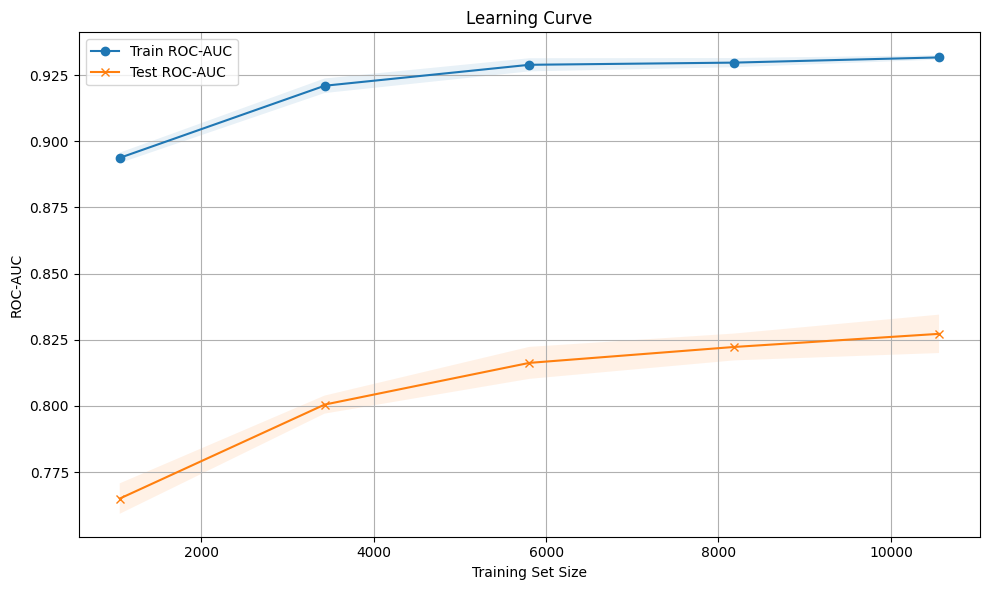

In [45]:
train_size, train_scores, test_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    cv=skf,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)


plt.figure(figsize=(10,6))
plt.plot(train_size, train_mean, label=f"Train ROC-AUC", marker="o")
plt.fill_between(train_size, train_mean + train_std, train_mean - train_std, alpha=0.1)
plt.plot(train_size, test_mean, label=f"Test ROC-AUC", marker="x")
plt.fill_between(train_size, test_mean + test_std, test_mean - test_std, alpha=0.1)
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Performance Curves

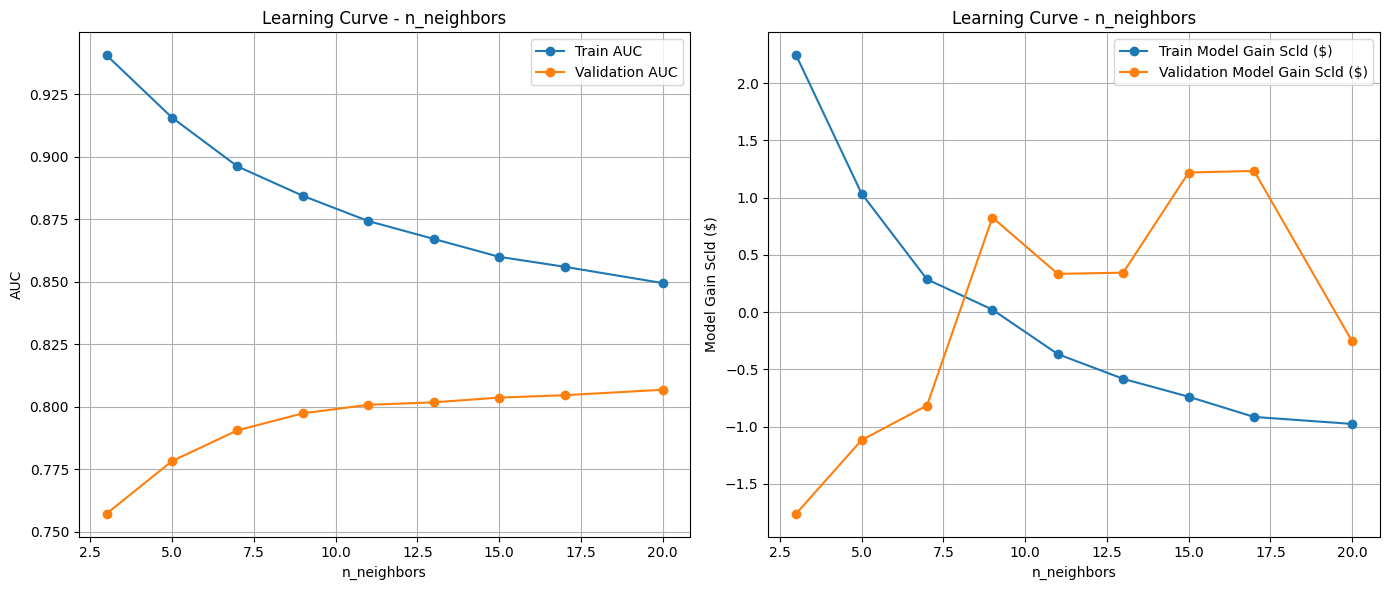

In [46]:
# Split
X_train, X_val, X_test, y_train, y_val, y_test = mod_prep.train_test_val_split(X, y, val_size=0.2, test_size=0.2, stratify=y, random_state=None)

# Escalado
std_scaler = StandardScaler()
X_train_scld = std_scaler.fit_transform(X_train)
X_val_scld = std_scaler.transform(X_val)
X_test_scld = std_scaler.transform(X_test)

# Modelo
knn_base = KNeighborsClassifier(weights="uniform", metric="manhattan")

# Parámetros
params_dict = {
    "n_neighbors": [3, 5, 7, 9, 11, 13, 15, 17, 20]
    #"weights": ["uniform", "distance"],
    #"metric": ["euclidean", "manhattan"]
}

# Score Económico
eco_score_dict = {
    "avg_tkt": avg_tkt,
    "churn_like": churn_like,
    "churn_dislike": churn_dislike
}

# Ploteo de curvas de performance
mod_prep.plot_performance_curves(
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    base_model=knn_base,
    params_dict=params_dict,
    eco_score_dict=eco_score_dict)

### Feature Selection

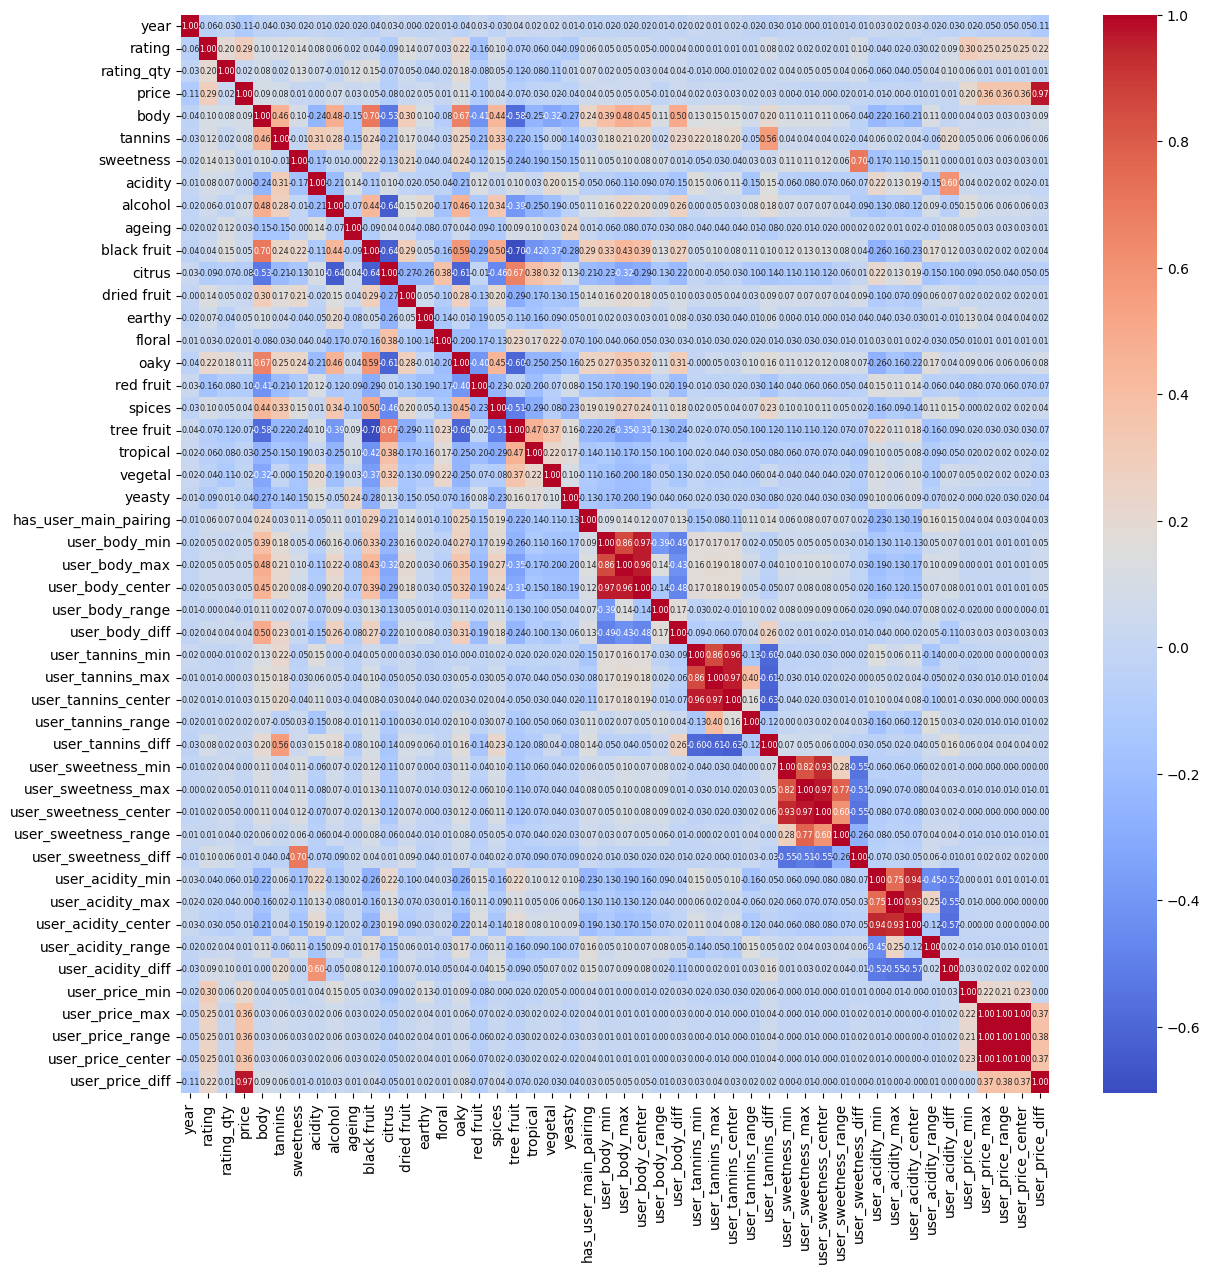

In [47]:
# Features Generales
X_train_df = pd.DataFrame(X_train_scld, columns=X.columns)
corr_matrix = X_train_df.corr()
plt.figure(figsize=(14, 14))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, annot_kws={"fontsize": "xx-small"}, fmt=".2f")
plt.show()

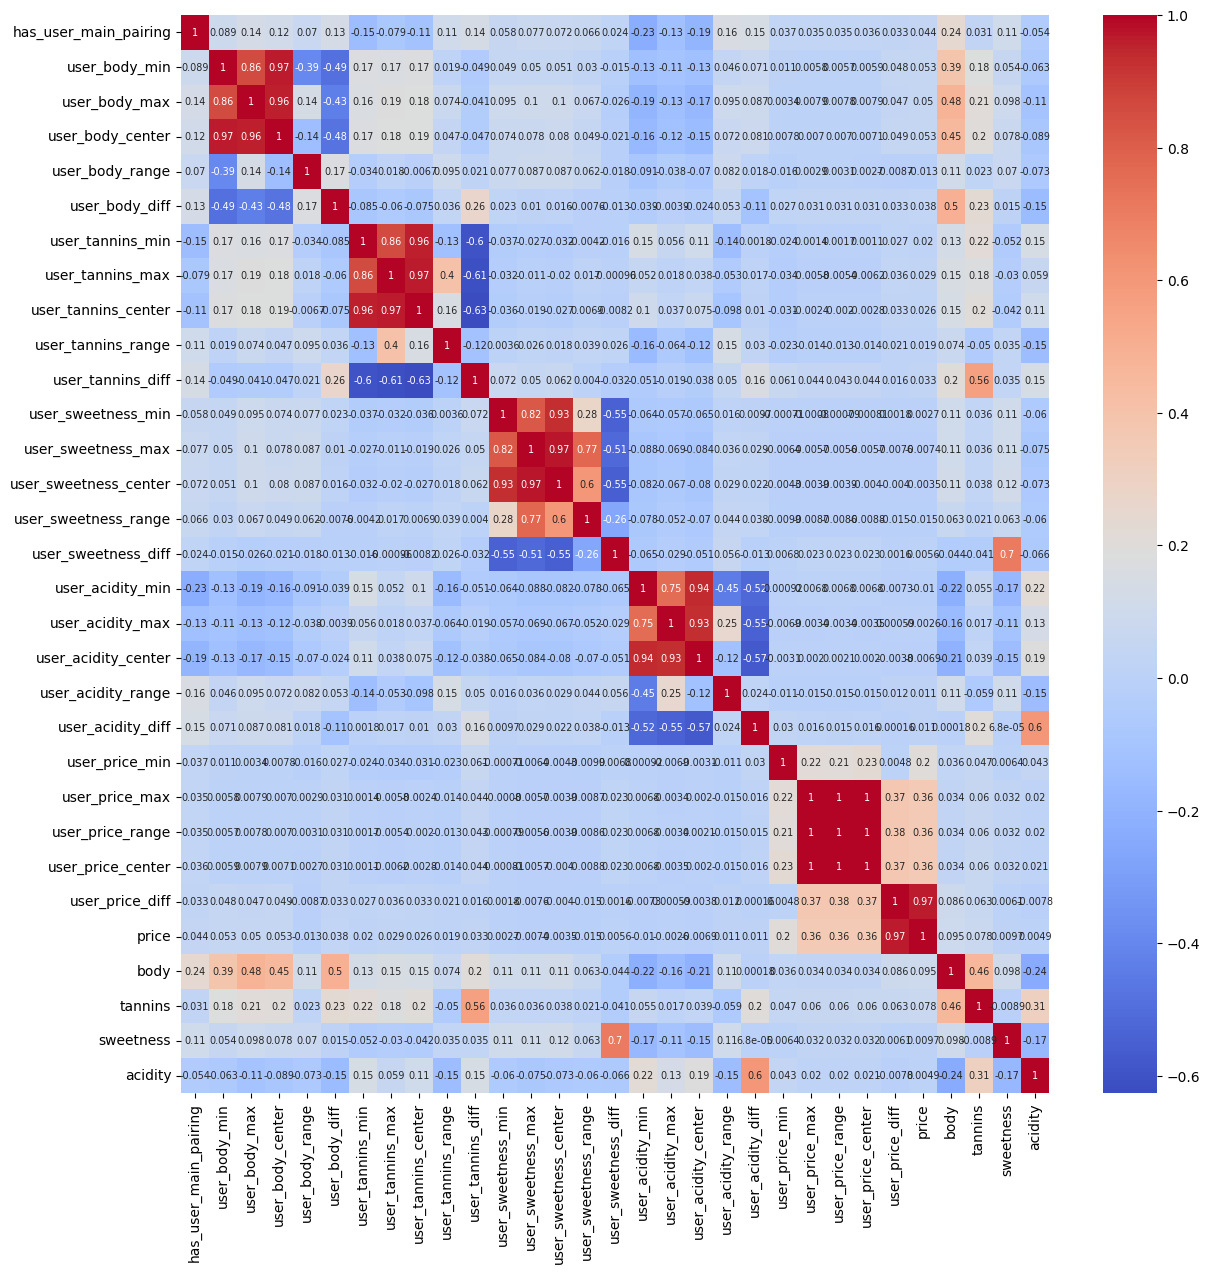

In [48]:
# User features
user_features = X.loc[:, "has_user_main_pairing":].columns.to_list()
wine_user_features = ["price", "body", "tannins", "sweetness", "acidity"]
user_corr_matrix = X_train_df[user_features + wine_user_features].corr()
plt.figure(figsize=(14, 14))
sns.heatmap(user_corr_matrix, cmap="coolwarm", annot=True, annot_kws={"fontsize": "x-small"})
plt.show()

*1 - Correlación Con Liked*

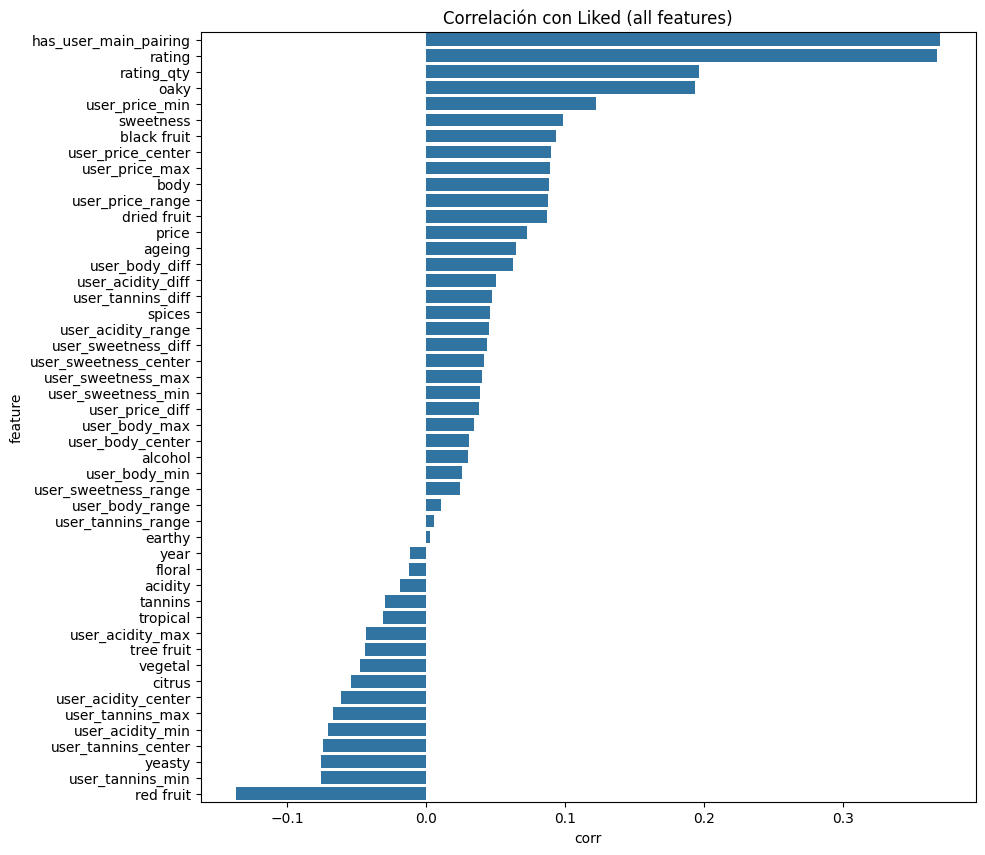

In [49]:
# Para el precio, la variable más importante es el max o el centro
# Para cada sabor, el valor más importante es la diff

liked_corr = pd.DataFrame(model_df_nocat.corr(method="pearson")["liked"].sort_values(ascending=False)).reset_index()
liked_corr.columns = ["feature", "corr"]
liked_corr = liked_corr.loc[1:, :]

plt.figure(figsize=(10, 10))
sns.barplot(data=liked_corr, y="feature", x="corr")
plt.title("Correlación con Liked (all features)")
plt.show()


*2 - SelectKBest*

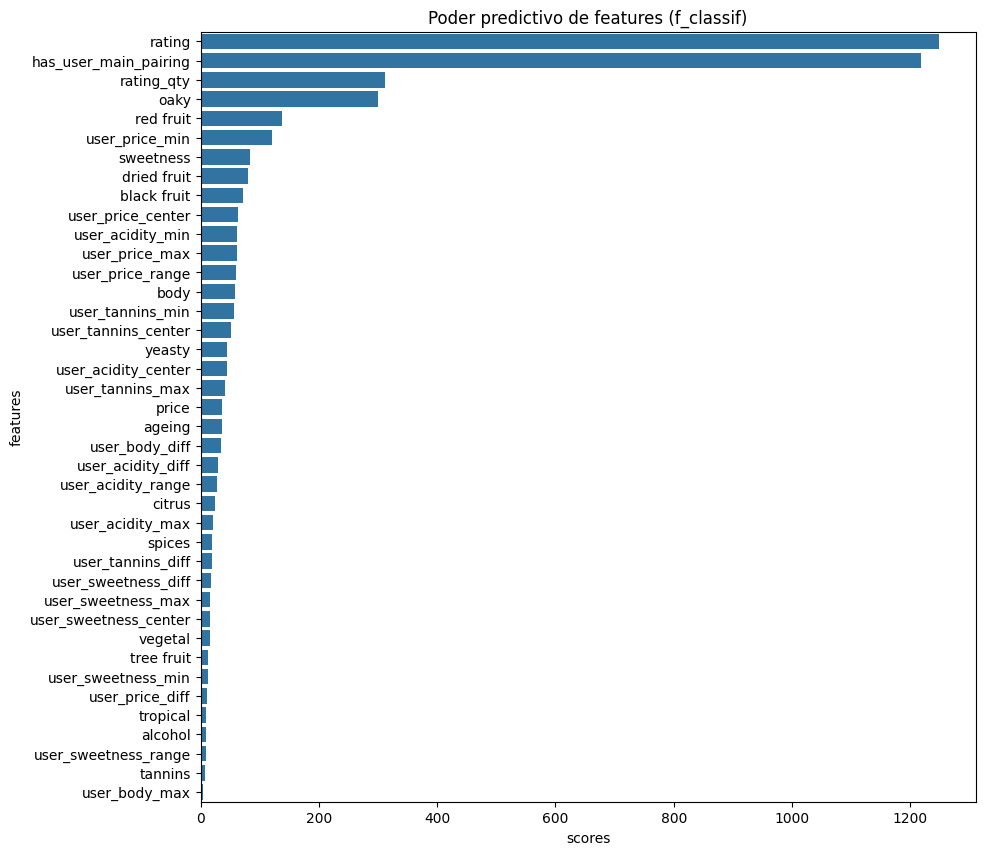

In [50]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k="all")

X_train_select = selector.fit_transform(X_train_scld, y_train)

scores = selector.scores_
pvalues = selector.pvalues_

features_scores = pd.DataFrame({
    "features": X.columns,
    "scores": scores,
    "pvalues": pvalues
})

features_scores = features_scores.sort_values(by="scores", ascending=False)
top = features_scores.head(40)

plt.figure(figsize=(10, 10))
sns.barplot(data=top, y="features", x="scores")
plt.title("Poder predictivo de features (f_classif)")
plt.show()

## KNN User Pruned

*Feature Selection*

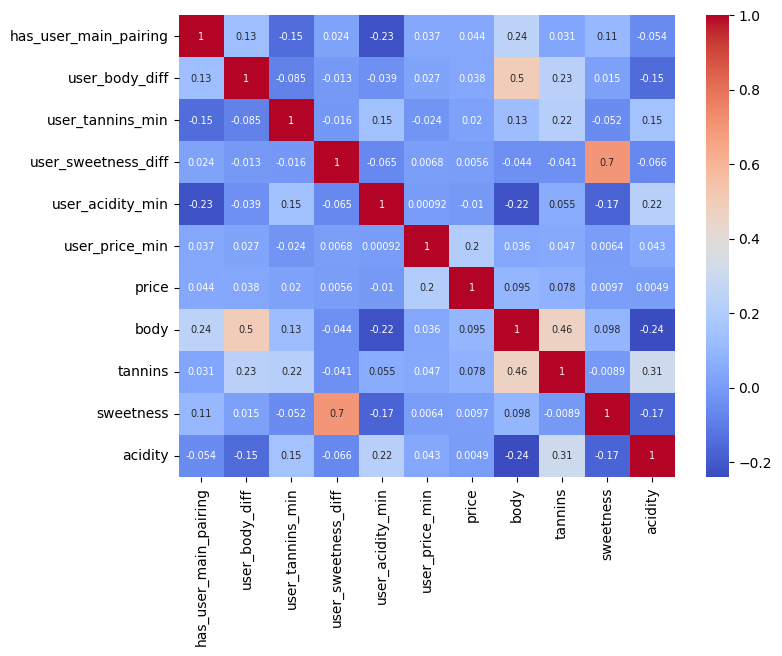

In [51]:
# Revisamos que no haya fuerte correlación (colinealidad)
user_features_pruned = [
    "has_user_main_pairing", "user_body_diff", "user_tannins_diff",
    "user_sweetness_diff", "user_acidity_diff","user_price_center"
]

user_features_pruned2 = [
    "has_user_main_pairing", "user_body_diff", "user_tannins_min",
    "user_sweetness_diff", "user_acidity_min","user_price_min"
]

wine_user_features = ["price", "body", "tannins", "sweetness", "acidity"]
user_pruned_corr_matrix = X_train_df[user_features_pruned2 + wine_user_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(user_pruned_corr_matrix, cmap="coolwarm", annot=True, annot_kws={"fontsize": "x-small"})
plt.show()

*Feature Prunning*

In [52]:
user_features = model_df_nocat.loc[:, "has_user_main_pairing":].columns.to_list()

user_features_pruned = [
    "has_user_main_pairing", "user_body_diff", "user_tannins_diff",
    "user_sweetness_diff", "user_acidity_diff","user_price_center"
]

user_features_pruned2 = [
    "has_user_main_pairing", "user_body_diff", "user_tannins_min",
    "user_sweetness_diff", "user_acidity_min","user_price_min"
]

cols_to_prune = [ft for ft in user_features if ft not in user_features_pruned2]


wine_features_pruned = [
    'vegetal',
    'citrus',
    'spices',
    'tree fruit',
    'tropical',
    'alcohol',
    'floral',
    'earthy',
    'year'
]

cols_to_prune = cols_to_prune #+ wine_features_pruned
cols_to_prune.append("liked")
cols_to_prune

['user_body_min',
 'user_body_max',
 'user_body_center',
 'user_body_range',
 'user_tannins_max',
 'user_tannins_center',
 'user_tannins_range',
 'user_tannins_diff',
 'user_sweetness_min',
 'user_sweetness_max',
 'user_sweetness_center',
 'user_sweetness_range',
 'user_acidity_max',
 'user_acidity_center',
 'user_acidity_range',
 'user_acidity_diff',
 'user_price_max',
 'user_price_range',
 'user_price_center',
 'user_price_diff',
 'liked']

*Evaluación de performance*

In [53]:
X = model_df_nocat.drop(columns=cols_to_prune)
y = model_df_nocat["liked"]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
        # n_neighbors=15,
        # weights="uniform",
        # algorithm="auto",
        # metric="euclidean"
        # ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True)
scoring_metrics = ["roc_auc", "accuracy", "precision_macro", "recall_macro", "f1_macro"]
scores = cross_validate(pipeline, X, y, cv=skf, scoring=scoring_metrics)

metrics_summary = {
    "roc_auc": scores["test_roc_auc"],
    "accuracy": scores["test_accuracy"],
    "precision_macro": scores["test_precision_macro"],
    "recall_macro": scores["test_recall_macro"],
    "f1_macro": scores["test_f1_macro"]
}

metrics_df = pd.DataFrame({
    "Mean": {k: v.mean() for k, v in metrics_summary.items()},
    "Std": {k: v.std() for k, v in metrics_summary.items()},
    "Coef. Var": {k: v.std() / v.mean() for k, v in metrics_summary.items()}
})

metrics_df

,Mean,Std,Coef. Var
roc_auc,0.847170,0.005556,0.006559
accuracy,0.797166,0.003443,0.004319
precision_macro,0.783200,0.004648,0.005935
recall_macro,0.753577,0.003990,0.005295
f1_macro,0.763996,0.003958,0.005181


*Learning Curves*

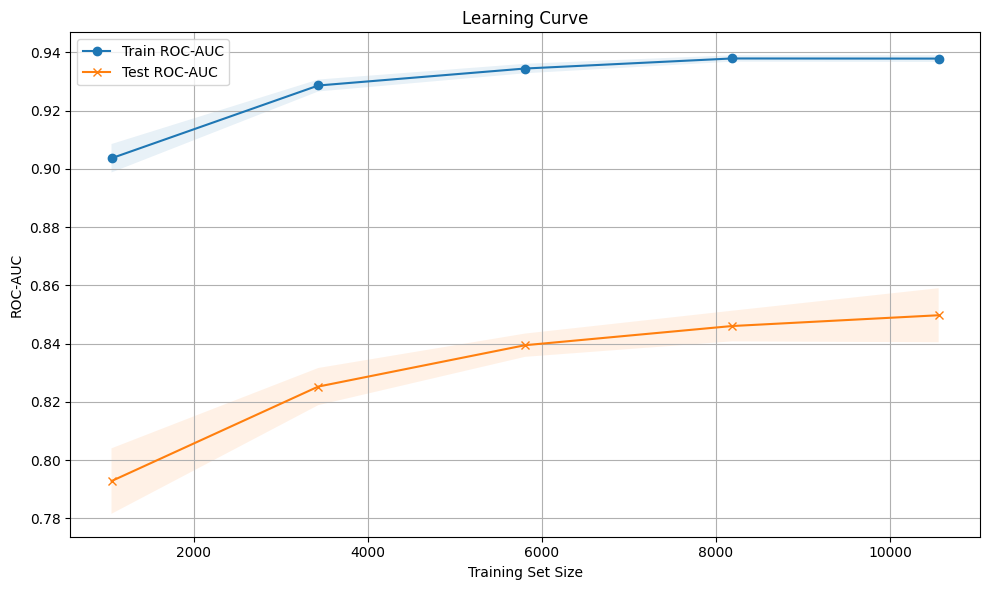

In [54]:
train_size, train_scores, test_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    cv=skf,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)


plt.figure(figsize=(10,6))
plt.plot(train_size, train_mean, label=f"Train ROC-AUC", marker="o")
plt.fill_between(train_size, train_mean + train_std, train_mean - train_std, alpha=0.1)
plt.plot(train_size, test_mean, label=f"Test ROC-AUC", marker="x")
plt.fill_between(train_size, test_mean + test_std, test_mean - test_std, alpha=0.1)
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

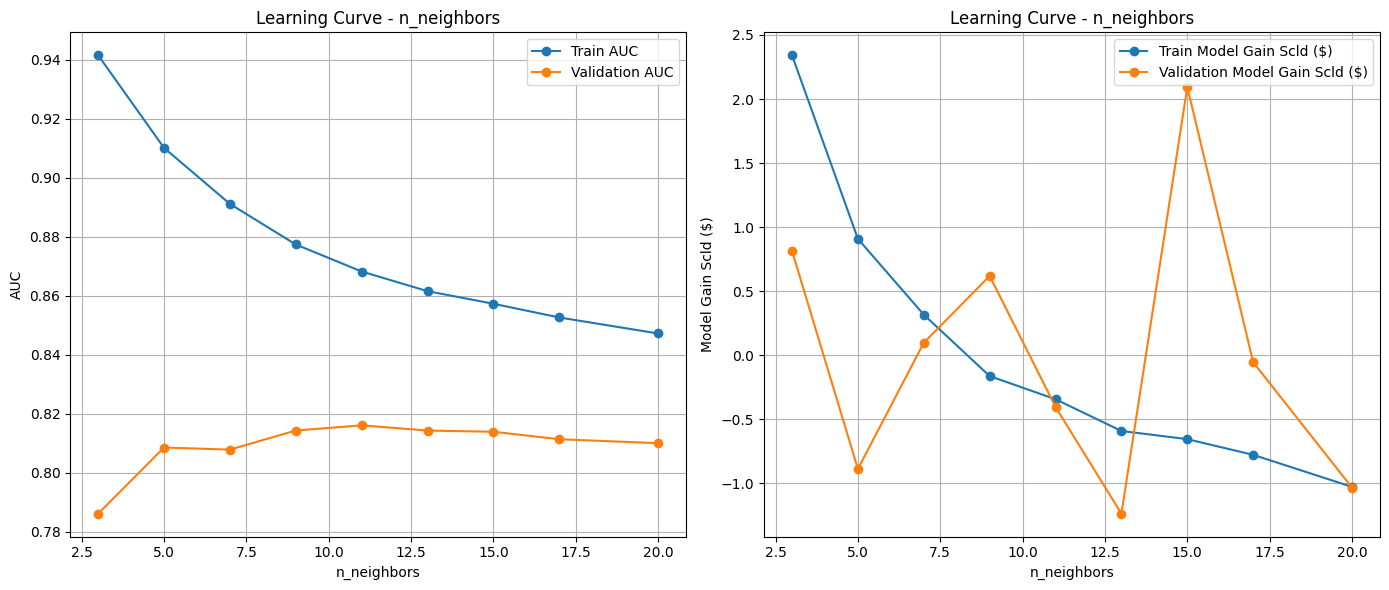

In [55]:
# Split
X_train, X_val, X_test, y_train, y_val, y_test = mod_prep.train_test_val_split(X, y, val_size=0.2, test_size=0.2, stratify=y, random_state=None)

# Escalado
std_scaler = StandardScaler()
X_train_scld = std_scaler.fit_transform(X_train)
X_val_scld = std_scaler.transform(X_val)
X_test_scld = std_scaler.transform(X_test)

# Modelo
knn_base = KNeighborsClassifier()

# Parámetros
params_dict = {
    "n_neighbors": [3, 5, 7, 9, 11, 13, 15, 17, 20]
    #"weights": ["uniform", "distance"],
    #"metric": ["euclidean", "manhattan"]
}

# Score Económico
eco_score_dict = {
    "avg_tkt": avg_tkt,
    "churn_like": churn_like,
    "churn_dislike": churn_dislike
}

# Ploteo de curvas de performance
mod_prep.plot_performance_curves(
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    base_model=knn_base,
    params_dict=params_dict,
    eco_score_dict=eco_score_dict)

*1 - Correlación con Liked*

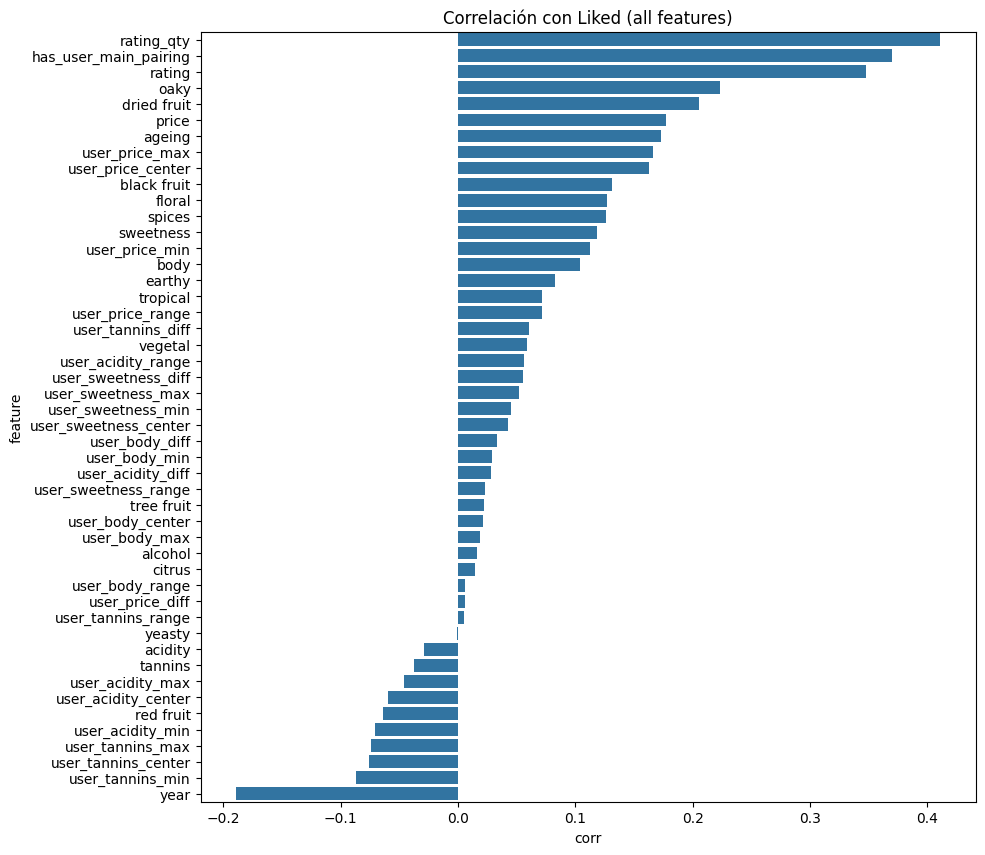

In [56]:
# Para el precio, la variable más importante es el max o el centro
# Para cada sabor, el valor más importante es la diff

liked_corr = pd.DataFrame(model_df_nocat.corr(method="spearman")["liked"].sort_values(ascending=False)).reset_index()
liked_corr.columns = ["feature", "corr"]
liked_corr = liked_corr.loc[1:, :]

plt.figure(figsize=(10, 10))
sns.barplot(data=liked_corr, y="feature", x="corr")
plt.title("Correlación con Liked (all features)")
plt.show()


*2 - SelectKBest*

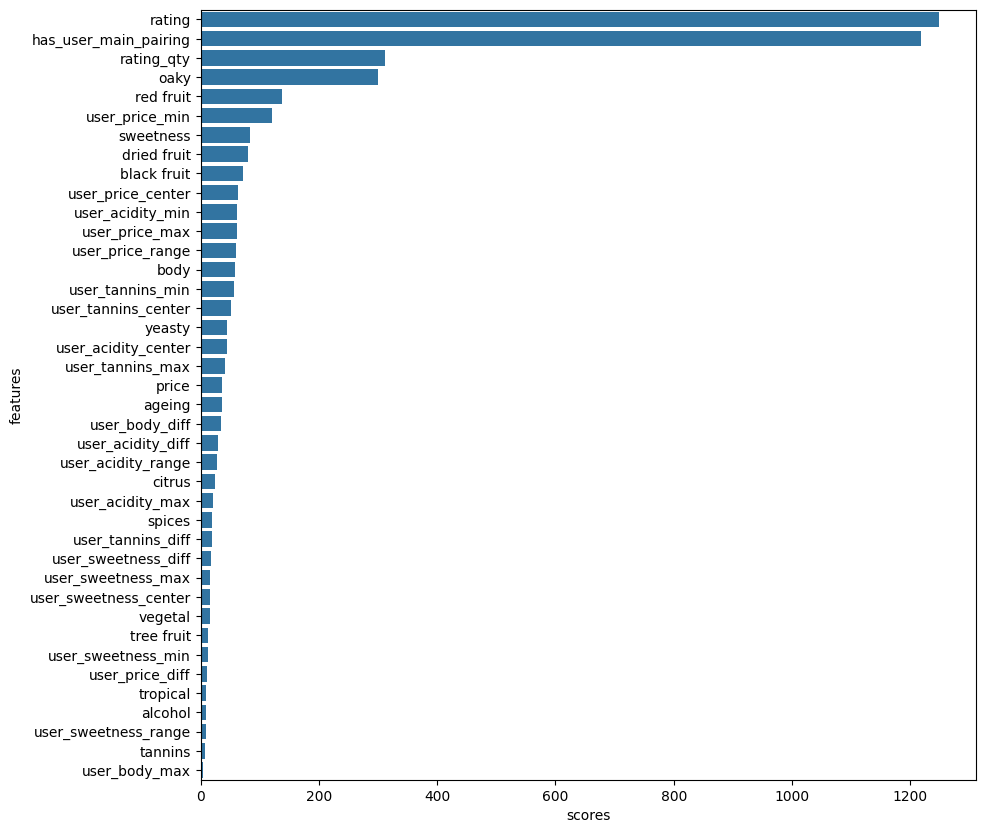

In [57]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

selector = SelectKBest(score_func=f_classif, k="all")

X_train_select = selector.fit_transform(X_train_scld, y_train)

scores = selector.scores_
pvalues = selector.pvalues_

features_scores = pd.DataFrame({
    "features": X.columns,
    "scores": scores,
    "pvalues": pvalues
})

features_scores = features_scores.sort_values(by="scores", ascending=False)
features_scores = features_scores

plt.figure(figsize=(10, 10))
sns.barplot(data=top, y="features", x="scores")
plt.show()

*3 - SequentialFeatureSelector*

## KNN SFS Selected

*Feature Selection*

In [87]:
X = model_df_nocat.drop(columns=["liked"])
y = model_df_nocat["liked"]

# Split
X_train, X_val, X_test, y_train, y_val, y_test = mod_prep.train_test_val_split(X, y, val_size=0.2, test_size=0.2, stratify=y, random_state=None)

# Escalado
std_scaler = StandardScaler()
X_train_scld = std_scaler.fit_transform(X_train)
X_val_scld = std_scaler.transform(X_val)
X_test_scld = std_scaler.transform(X_test)

knn = KNeighborsClassifier()

sfs = SequentialFeatureSelector(
    estimator=knn,
    n_features_to_select=20,
    direction="forward",
    scoring="roc_auc",
    cv=5
)

sfs.fit(X_train_scld, y_train)

SequentialFeatureSelector(estimator=KNeighborsClassifier(),
                          n_features_to_select=20, scoring='roc_auc')

In [247]:
model_df_nocat

,liked,year,rating,rating_qty,price,body,tannins,sweetness,acidity,alcohol,ageing,black fruit,citrus,dried fruit,earthy,floral,oaky,red fruit,spices,tree fruit,tropical,vegetal,yeasty,has_user_main_pairing,user_body_min,user_body_max,user_body_center,user_body_range,user_body_diff,user_tannins_min,user_tannins_max,user_tannins_center,user_tannins_range,user_tannins_diff,user_sweetness_min,user_sweetness_max,user_sweetness_center,user_sweetness_range,user_sweetness_diff,user_acidity_min,user_acidity_max,user_acidity_center,user_acidity_range,user_acidity_diff,user_price_min,user_price_max,user_price_range,user_price_center,user_price_diff
0,1,2016.0,4.3,3243.0,24.95,0.5392,0.2904,0.2272,0.6372,0.1350,0.0061,0.2825,0.0130,0.0154,0.1242,0.0239,0.3153,0.1100,0.0820,0.0106,0.0028,0.0065,0.0077,1,0.2896,0.519075,0.404338,0.229475,0.020125,0.393100,0.67500,0.534050,0.281900,-0.1027,0.0000,0.15140,0.075700,0.15140,0.0758,0.51470,0.8132,0.663950,0.29850,0.0000,15,46.0,31.0,30.5,-5.55
1,0,2022.0,3.5,102.0,10.99,0.6731,0.2431,0.1652,0.3639,0.1400,0.0097,0.3973,0.0019,0.0058,0.0988,0.0019,0.2578,0.1492,0.0543,0.0039,0.0039,0.0039,0.0116,1,0.3050,0.610000,0.457500,0.305000,0.063100,0.373300,0.50300,0.438150,0.129700,-0.1302,0.1328,0.18270,0.157750,0.04990,0.0000,0.47920,0.8500,0.664600,0.37080,-0.1153,1,15.0,14.0,8.0,2.99
2,1,2016.0,4.0,1520.0,26.99,0.6178,0.4387,0.3087,0.4437,0.1400,0.0154,0.3282,0.0000,0.0154,0.1236,0.0309,0.3205,0.1158,0.0425,0.0000,0.0000,0.0000,0.0077,1,0.3050,0.610000,0.457500,0.305000,0.007800,0.373300,0.50300,0.438150,0.129700,0.0000,0.2106,0.42480,0.317700,0.21420,0.0000,0.36620,0.4157,0.390950,0.04950,0.0280,20,34.0,14.0,27.0,-0.01
3,0,2023.0,3.9,25.0,20.00,0.4022,0.3621,0.0486,0.4250,0.1402,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1,0.4528,0.479500,0.466150,0.026700,-0.050600,0.543900,0.57015,0.557025,0.026250,-0.1818,0.1084,0.12820,0.118300,0.01980,-0.0598,0.51410,0.5435,0.528800,0.02940,-0.0891,18,23.0,5.0,20.5,-0.50
4,0,2021.0,3.8,69.0,17.00,0.4671,0.4884,0.1502,0.7551,0.1399,0.0073,0.2763,0.0024,0.0147,0.1394,0.0122,0.2347,0.1663,0.1100,0.0049,0.0000,0.0244,0.0073,1,0.5481,0.725200,0.636650,0.177100,-0.081000,0.304500,0.37010,0.337300,0.065600,0.1183,0.1806,0.38500,0.282800,0.20440,-0.0304,0.45160,0.5262,0.488900,0.07460,0.2289,13,18.0,5.0,15.5,1.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13193,1,2023.0,4.0,25.0,20.24,0.4086,0.3639,0.1287,0.5511,0.1332,0.0030,0.0060,0.2232,0.0060,0.0804,0.0149,0.0030,0.2946,0.0060,0.2679,0.0446,0.0238,0.0268,1,0.4545,0.550800,0.502650,0.096300,-0.045900,0.362475,0.38220,0.372337,0.019725,0.0000,0.1365,0.18195,0.159225,0.04545,-0.0078,0.49635,0.5301,0.513225,0.03375,0.0210,18,23.0,5.0,20.5,-0.26
13194,1,2018.0,4.1,297.0,21.98,0.6503,0.4081,0.2983,0.5225,0.1450,0.0111,0.3344,0.0044,0.0156,0.1422,0.0144,0.2911,0.1033,0.0711,0.0011,0.0000,0.0011,0.0100,1,0.3000,0.640100,0.470050,0.340100,0.010200,0.415000,0.44250,0.428750,0.027500,-0.0069,0.3004,0.42480,0.362600,0.12440,-0.0021,0.52970,0.5504,0.540050,0.02070,-0.0072,13,23.0,10.0,18.0,3.98
13195,1,2010.0,4.2,567.0,45.00,0.7651,0.5452,0.1319,0.5185,0.1406,0.0053,0.2965,0.0021,0.0138,0.1286,0.0096,0.3677,0.0627,0.0956,0.0021,0.0000,0.0032,0.0128,1,0.6898,0.850000,0.769900,0.160200,0.000000,0.304500,0.48050,0.392500,0.176000,0.0647,0.1051,0.14560,0.125350,0.04050,0.0000,0.54990,0.8132,0.681550,0.26330,-0.0314,15,46.0,31.0,30.5,14.50
13196,0,2022.0,3.5,25.0,20.00,0.8500,0.5732,0.0361,0.6704,0.1400,0.0000,0.4194,0.0000,0.0215,0.1075,0.0108,0.2366,0.1183,0.0753,0.0000,0.0000,0.0000,0.0108,1,0.6100,0.649100,0.629550,0.039100,0.200900,0.373300,0.50300,0.438150,0.129700,0.0702,0.0000,0.13280,0.066400,0.13280,0.0000,0.47920,0.8500,0.664600,0.37080,0.0000,15,2000.0,1985.0,1007.5,5.00


*Feature Pruning*

In [277]:
X = model_df_nocat.drop(columns=["liked"])
y = model_df_nocat["liked"]
sfs_features = X.loc[:, sfs.get_support()].columns.to_list()
other_features = ["body", "user_price_min"]
sfs_features += [f for f in other_features if f not in sfs_features]
drop_cols = ["ageing", "tropical"]
sfs_features = [f for f in sfs_features if f not in drop_cols]
sfs_features

['year',
 'rating',
 'rating_qty',
 'price',
 'tannins',
 'sweetness',
 'acidity',
 'alcohol',
 'citrus',
 'dried fruit',
 'floral',
 'tree fruit',
 'has_user_main_pairing',
 'user_body_diff',
 'user_tannins_diff',
 'user_sweetness_diff',
 'user_acidity_diff',
 'user_price_diff',
 'body',
 'user_price_min']

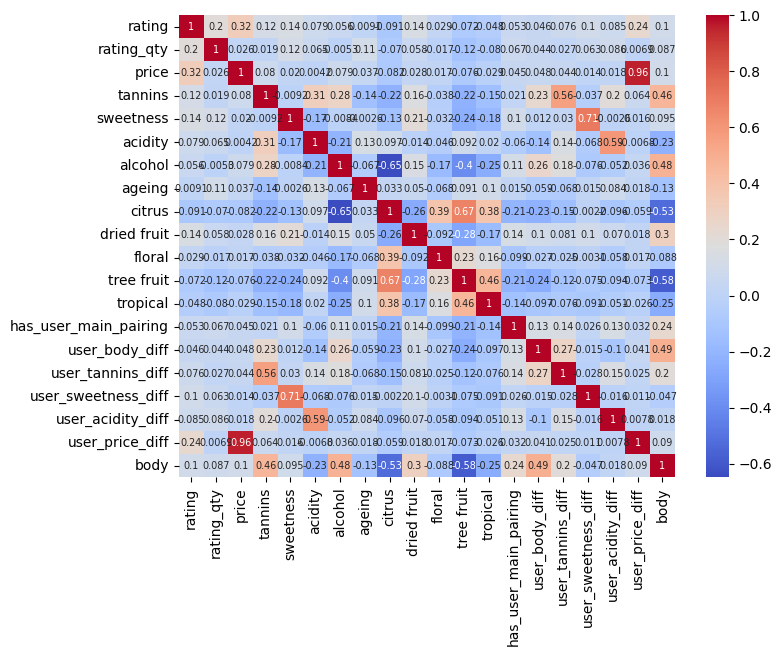

In [201]:
sfs_features_corr_matrix = X[sfs_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(sfs_features_corr_matrix, cmap="coolwarm", annot=True, annot_kws={"fontsize": "x-small"})
plt.show()

*Performance con CV*

In [280]:
X = model_df_nocat[sfs_features]
y = model_df_nocat["liked"]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
        # n_neighbors=15,
        # weights="uniform",
        # algorithm="auto",
        # metric="euclidean"
        # ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True)
scoring_metrics = ["roc_auc", "accuracy", "precision_macro", "recall_macro", "f1_macro"]
scores = cross_validate(pipeline, X, y, cv=skf, scoring=scoring_metrics)

metrics_summary = {
    "roc_auc": scores["test_roc_auc"],
    "accuracy": scores["test_accuracy"],
    "precision_macro": scores["test_precision_macro"],
    "recall_macro": scores["test_recall_macro"],
    "f1_macro": scores["test_f1_macro"]
}

metrics_df = pd.DataFrame({
    "Mean": {k: v.mean() for k, v in metrics_summary.items()},
    "Std": {k: v.std() for k, v in metrics_summary.items()},
    "Coef. Var": {k: v.std() / v.mean() for k, v in metrics_summary.items()}
})

metrics_df

,Mean,Std,Coef. Var
roc_auc,0.869011,0.012268,0.014117
accuracy,0.816032,0.009285,0.011378
precision_macro,0.805386,0.011022,0.013685
recall_macro,0.775814,0.010812,0.013936
f1_macro,0.786660,0.011047,0.014043


*Evaluación de Performance*


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

           0       0.86      0.72      0.78      2724
           1       0.86      0.94      0.90      5194

    accuracy                           0.86      7918
   macro avg       0.86      0.83      0.84      7918
weighted avg       0.86      0.86      0.86      7918



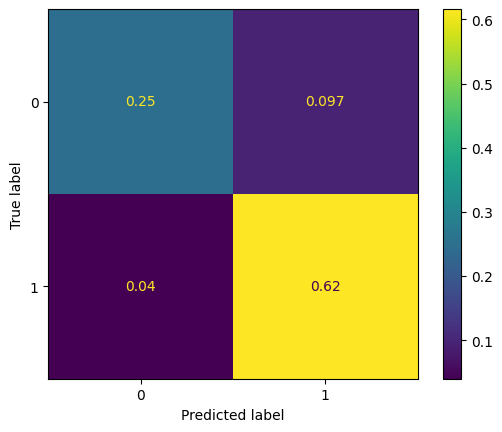

AUC Train: 0.9433818432202072

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

           0       0.78      0.65      0.71       908
           1       0.83      0.91      0.87      1732

    accuracy                           0.82      2640
   macro avg       0.81      0.78      0.79      2640
weighted avg       0.82      0.82      0.81      2640



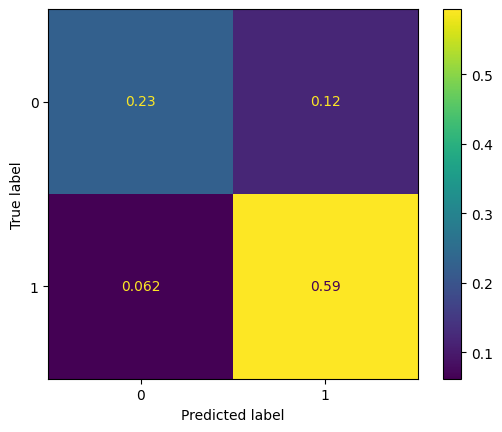

AUC Test: 0.8704093584356656


In [276]:
X = model_df_nocat[sfs_features]
y = model_df_nocat["liked"]


# Split
X_train, X_val, X_test, y_train, y_val, y_test = mod_prep.train_test_val_split(X, y, val_size=0.2, test_size=0.2, stratify=y, random_state=0)

# Escalado
std_scaler = StandardScaler()
X_train_scld = std_scaler.fit_transform(X_train)
X_val_scld = std_scaler.transform(X_val)
X_test_scld = std_scaler.transform(X_test)


knn = KNeighborsClassifier()

# Entrenamiento
knn.fit(X_train_scld, y_train)

# Predicción de train
y_train_proba = knn.predict_proba(X_train_scld)[:, 1]
y_train_pred = knn.predict(X_train_scld)
cm_train = confusion_matrix(y_train, y_train_pred, normalize="all")
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=knn.classes_)

# Predicción de val
y_val_proba = knn.predict_proba(X_val_scld)[:, 1]
y_val_pred = knn.predict(X_val_scld)
cm_val = confusion_matrix(y_val, y_val_pred, normalize="all")
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=knn.classes_)

# Visualización de resultados
print("\n----------------------------------------------------\n")
print("Train Metrics:\n")
print(classification_report(y_train, y_train_pred))
disp_train.plot()
plt.show()
print("AUC Train:", roc_auc_score(y_train, y_train_proba))
print("\n----------------------------------------------------\n")
print("Test Metrics:\n")
print(classification_report(y_val, y_val_pred))
disp_val.plot()
plt.show()
print("AUC Test:", roc_auc_score(y_val, y_val_proba))

*Learning Curve*

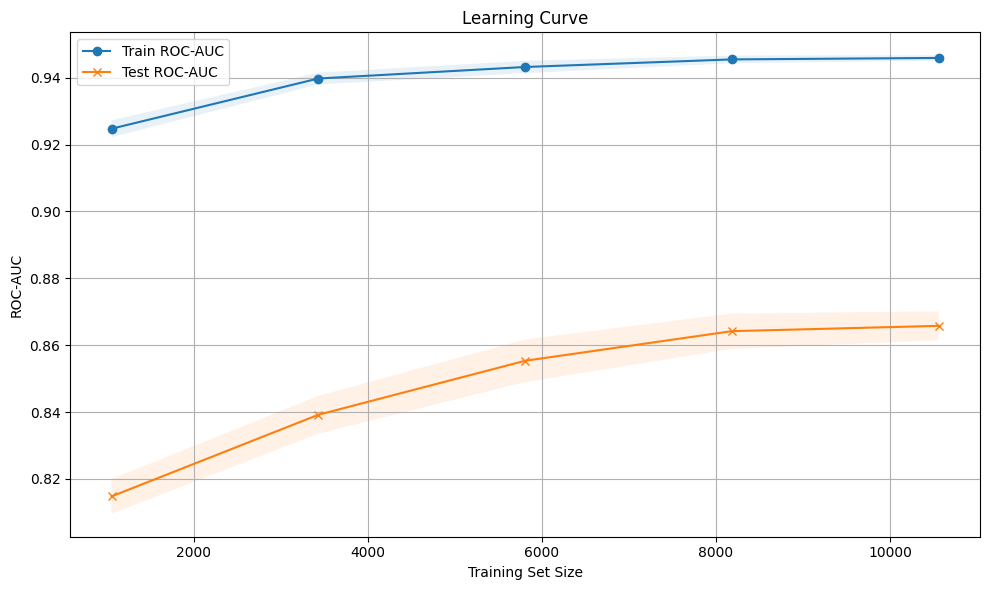

In [281]:
train_size, train_scores, test_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    cv=skf,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)


plt.figure(figsize=(10,6))
plt.plot(train_size, train_mean, label=f"Train ROC-AUC", marker="o")
plt.fill_between(train_size, train_mean + train_std, train_mean - train_std, alpha=0.1)
plt.plot(train_size, test_mean, label=f"Test ROC-AUC", marker="x")
plt.fill_between(train_size, test_mean + test_std, test_mean - test_std, alpha=0.1)
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

*Performance Curves*

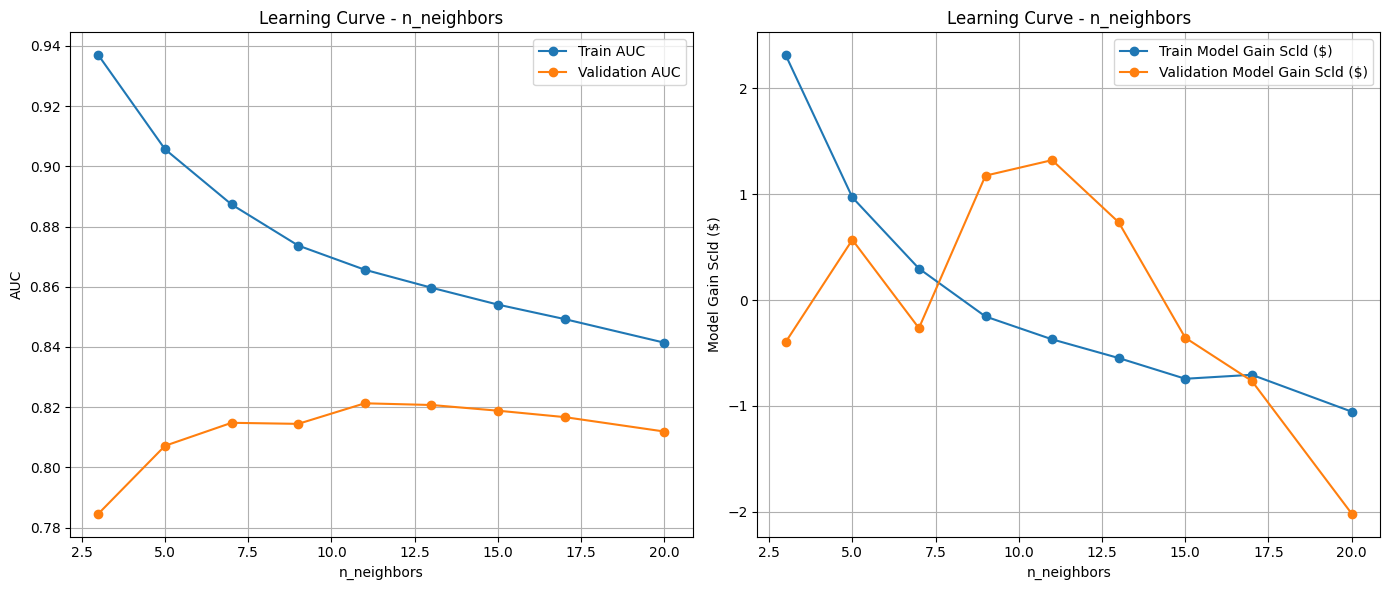

In [283]:
# Split
X_train, X_val, X_test, y_train, y_val, y_test = mod_prep.train_test_val_split(X, y, val_size=0.2, test_size=0.2, stratify=y, random_state=0)

# Escalado
std_scaler = StandardScaler()
X_train_scld = std_scaler.fit_transform(X_train)
X_val_scld = std_scaler.transform(X_val)
X_test_scld = std_scaler.transform(X_test)

# Modelo
knn_base = KNeighborsClassifier()

# Parámetros
params_dict = {
    "n_neighbors": [3, 5, 7, 9, 11, 13, 15, 17, 20]
    #"weights": ["uniform", "distance"],
    #"metric": ["euclidean", "manhattan"]
}

# Score Económico
eco_score_dict = {
    "avg_tkt": avg_tkt,
    "churn_like": churn_like,
    "churn_dislike": churn_dislike
}

# Ploteo de curvas de performance
mod_prep.plot_performance_curves(
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    base_model=knn_base,
    params_dict=params_dict,
    eco_score_dict=eco_score_dict)

*Corr Matrix*

*Corr Con Liked*

*SelectKBest*

In [ ]:
    # TODO:
    # 1. Ploteo de curvas de rendimiento con diferentes parámetros - OK
    # 2. Feature Selection - OK
        # 2.1. Ordenar Código KNN -> 1. Correlación, 2. SelectKBest, 3. SequentialFeatureSelection.
        # 2.2. Probar rendimiento de modelo con cada uno -> Pipeline + Learning Curves + Performance Curves + Corr Matrix.
        # 2.3. Llegar a una conclusión -> Elegir qué features vamos a usar para pasar al siguiente paso.

    # 3. Optimización de parámetros con grid search / finetunning
    # 4. Generación de matrices de confusión y medición económica

## Evaluación de Random Forest

In [63]:
from imblearn.under_sampling import RandomUnderSampler
# Asignación de valor extremo cuando no hay precio_max
model_df_nocat.loc[model_df_nocat["user_price_max"].isna(), "user_price_max"] = 9999

# División del DataFrame en features independientes y dependientes
X = model_df_nocat.drop(columns=["liked"])
y = model_df_nocat["liked"]

# Pipeline con oversampler y modelo para aplicarlo en cada Fold del CV
pipeline = Pipeline([
    ("oversampler", SMOTE()),
    ("model", RandomForestClassifier())
])

# Aplicación de cross validation y obtención de métricas
skf = StratifiedKFold(n_splits=5, shuffle=True)
scoring_metrics = ["roc_auc", "accuracy", "precision_macro", "recall_macro", "f1_macro"]
scores = cross_validate(pipeline, X, y, cv=skf, scoring=scoring_metrics)

# Resumen de métricas del CV
metrics_summary = {
    "roc_auc": scores["test_roc_auc"],
    "accuracy": scores["test_accuracy"],
    "precision_macro": scores["test_precision_macro"],
    "recall_macro": scores["test_recall_macro"],
    "f1_macro": scores["test_f1_macro"]
}

# Media, Desvío Estándar y Coef Var
metrics_df = pd.DataFrame({
    "Mean": {k: v.mean() for k, v in metrics_summary.items()},
    "Std": {k: v.std() for k, v in metrics_summary.items()},
    "Coef Var": {k: v.std() / v.mean() for k, v in metrics_summary.items()}
})

metrics_df

,Mean,Std,Coef Var
roc_auc,0.911449,0.003063,0.003361
accuracy,0.837778,0.004201,0.005015
precision_macro,0.819402,0.004539,0.005539
recall_macro,0.824498,0.005843,0.007087
f1_macro,0.821734,0.004880,0.005938


### Learning Curves

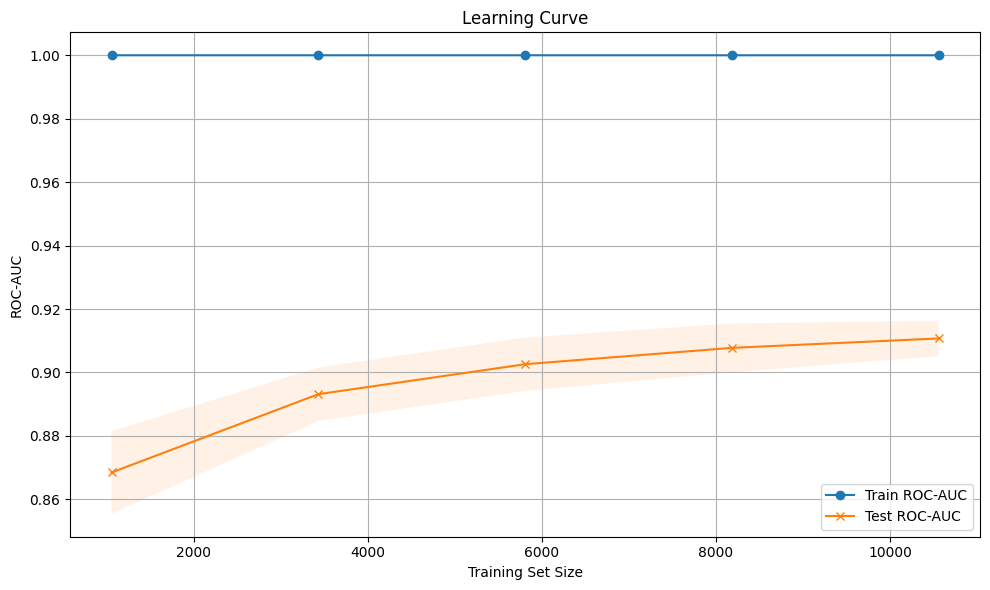

In [64]:
train_size, train_scores, test_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    cv=skf,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)


plt.figure(figsize=(10,6))
plt.plot(train_size, train_mean, label=f"Train ROC-AUC", marker="o")
plt.fill_between(train_size, train_mean + train_std, train_mean - train_std, alpha=0.1)
plt.plot(train_size, test_mean, label=f"Test ROC-AUC", marker="x")
plt.fill_between(train_size, test_mean + test_std, test_mean - test_std, alpha=0.1)
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Leakage Tests

In [65]:
model_df_nocat.columns

Index(['liked', 'year', 'rating', 'rating_qty', 'price', 'body', 'tannins',
       'sweetness', 'acidity', 'alcohol', 'ageing', 'black fruit', 'citrus',
       'dried fruit', 'earthy', 'floral', 'oaky', 'red fruit', 'spices',
       'tree fruit', 'tropical', 'vegetal', 'yeasty', 'has_user_main_pairing',
       'user_body_min', 'user_body_max', 'user_body_center', 'user_body_range',
       'user_body_diff', 'user_tannins_min', 'user_tannins_max',
       'user_tannins_center', 'user_tannins_range', 'user_tannins_diff',
       'user_sweetness_min', 'user_sweetness_max', 'user_sweetness_center',
       'user_sweetness_range', 'user_sweetness_diff', 'user_acidity_min',
       'user_acidity_max', 'user_acidity_center', 'user_acidity_range',
       'user_acidity_diff', 'user_price_min', 'user_price_max',
       'user_price_range', 'user_price_center', 'user_price_diff'],
      dtype='object')

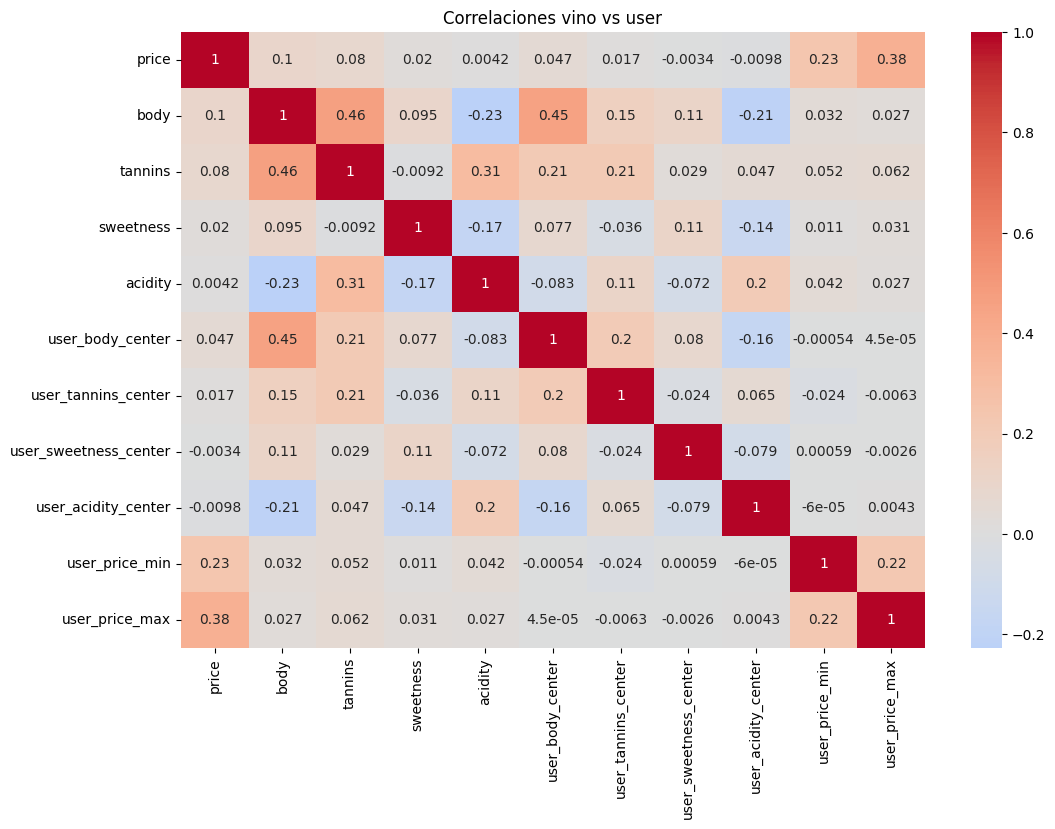

In [66]:
# Correlación entre variables propias del vino y las del usuario => Hay bastante correlación en algunos casos
wine_features = ['price', 'body', 'tannins','sweetness', 'acidity']
# user_features = ['user_body_min', 'user_body_max', 'user_tannins_min',
#        'user_tannins_max', 'user_sweetness_min', 'user_sweetness_max',
#        'user_acidity_min', 'user_acidity_max', 'user_price_min', 'user_price_max']

user_features = ['user_body_center', 'user_tannins_center', 'user_sweetness_center', 'user_acidity_center', 'user_price_min', 'user_price_max']

correlation_matrix = X[wine_features + user_features].corr()
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlaciones vino vs user")
plt.show()

In [67]:
X_wine_only = X[['year', 'rating', 'rating_qty', 'price', 'body', 'tannins',
       'sweetness', 'acidity', 'alcohol', 'ageing', 'black fruit', 'citrus',
       'dried fruit', 'earthy', 'floral', 'oaky', 'red fruit', 'spices',
       'tree fruit', 'tropical', 'vegetal', 'yeasty', 'has_user_main_pairing']]

pipeline_wine_only = Pipeline([
    ("model", RandomForestClassifier())
])

skf = StratifiedKFold(n_splits=5, shuffle=True)
wine_only_scores = cross_validate(pipeline_wine_only, X_wine_only, y, cv=skf, scoring=scoring_metrics)

# Resumen de métricas del CV
wine_only_metrics_summary = {
    "roc_auc": wine_only_scores["test_roc_auc"],
    "accuracy": wine_only_scores["test_accuracy"],
    "precision_macro": wine_only_scores["test_precision_macro"],
    "recall_macro": wine_only_scores["test_recall_macro"],
    "f1_macro": wine_only_scores["test_f1_macro"]
}

# Media, Desvío Estándar y Coef Var
wine_only_metrics_df = pd.DataFrame({
    "Mean": {k: v.mean() for k, v in wine_only_metrics_summary.items()},
    "Std": {k: v.std() for k, v in wine_only_metrics_summary.items()},
    "Coef Var": {k: v.std() / v.mean() for k, v in wine_only_metrics_summary.items()}
})

wine_only_metrics_df

,Mean,Std,Coef Var
roc_auc,0.835789,0.006537,0.007821
accuracy,0.779739,0.008841,0.011338
precision_macro,0.757238,0.010123,0.013369
recall_macro,0.746161,0.010532,0.014114
f1_macro,0.750832,0.010332,0.013761


In [68]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)
feature_importance = pd.DataFrame({
    "features": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)
feature_importance

,features,importance
2,rating_qty,0.086642
22,has_user_main_pairing,0.063726
27,user_body_diff,0.052621
42,user_acidity_diff,0.050729
1,rating,0.046707
37,user_sweetness_diff,0.045723
32,user_tannins_diff,0.036077
47,user_price_diff,0.035074
46,user_price_center,0.023271
15,oaky,0.021423


# Tests

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# División del DataFrame en features independientes y dependiente
X = model_df_nocat.drop(columns="liked")
y = model_df_nocat["liked"]

# Pipeline con oversampler y modelo para aplicarlo en cada Fold del CV
pipeline = Pipeline([
    ("oversampler", SMOTE()),
    ("scaler", StandardScaler()),
    #("model", SVC(probability=True))
    ("model", LogisticRegression())
])

# Aplicación de cross validation y obtención de métricas
skf = StratifiedKFold(n_splits=5, shuffle=True)
scoring_metrics = ["roc_auc", "accuracy", "precision_macro", "recall_macro", "f1_macro"]
scores = cross_validate(pipeline, X, y, cv=skf, scoring=scoring_metrics)

# Resumen de métricas del CV
metrics_summary = {
    "roc_auc": scores["test_roc_auc"],
    "accuracy": scores["test_accuracy"],
    "precision_macro": scores["test_precision_macro"],
    "recall_macro": scores["test_recall_macro"],
    "f1_macro": scores["test_f1_macro"]
}

# Media, Desvío Estándar y Coef Var
metrics_df = pd.DataFrame({
    "Mean": {k: v.mean() for k, v in metrics_summary.items()},
    "Std": {k: v.std() for k, v in metrics_summary.items()},
    "Coef Var": {k: v.std() / v.mean() for k, v in metrics_summary.items()}
})

metrics_df

,Mean,Std,Coef Var
roc_auc,0.824494,0.010936,0.013264
accuracy,0.762465,0.007996,0.010487
precision_macro,0.737469,0.008467,0.011481
recall_macro,0.742110,0.008445,0.011379
f1_macro,0.739503,0.008413,0.011377


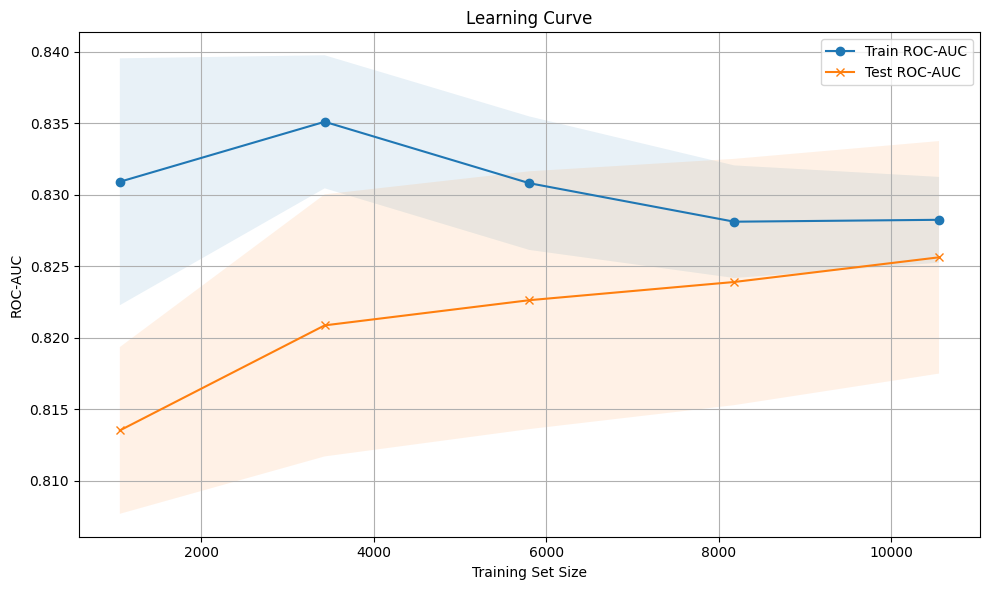

In [70]:
train_size, train_scores, test_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    cv=skf,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)


plt.figure(figsize=(10,6))
plt.plot(train_size, train_mean, label=f"Train ROC-AUC", marker="o")
plt.fill_between(train_size, train_mean + train_std, train_mean - train_std, alpha=0.1)
plt.plot(train_size, test_mean, label=f"Test ROC-AUC", marker="x")
plt.fill_between(train_size, test_mean + test_std, test_mean - test_std, alpha=0.1)
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Evaluación de Oversampling

### Modelo Base

In [71]:
# Instanciación de modelo RandomForest base
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced"
)

### Evaluación de Algoritmos de Oversampling

In [72]:
# Cálculo de entropía del dataset
def calc_entropy(y):
    _, counts = np.unique(y, return_counts=True)
    prob = counts / counts.sum()
    return stats.entropy(prob, base=2)


H_set = calc_entropy(model_df_nooh["liked"])
print(H_set)

0.9285871907562633


# SMOTENC


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

           0       0.91      0.92      0.92      6926
           1       0.92      0.91      0.92      6926

    accuracy                           0.92     13852
   macro avg       0.92      0.92      0.92     13852
weighted avg       0.92      0.92      0.92     13852



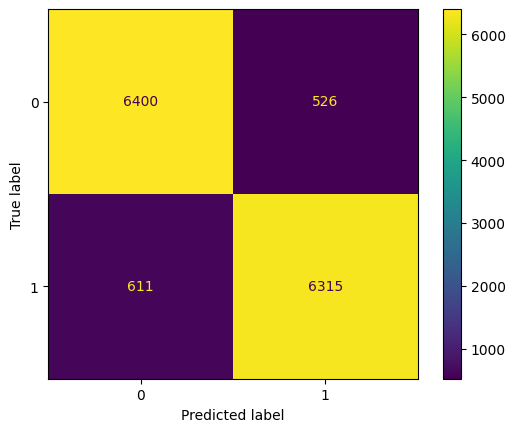

AUC Train: 0.9793361616041001

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1732
           1       0.87      0.84      0.86      1732

    accuracy                           0.86      3464
   macro avg       0.86      0.86      0.86      3464
weighted avg       0.86      0.86      0.86      3464



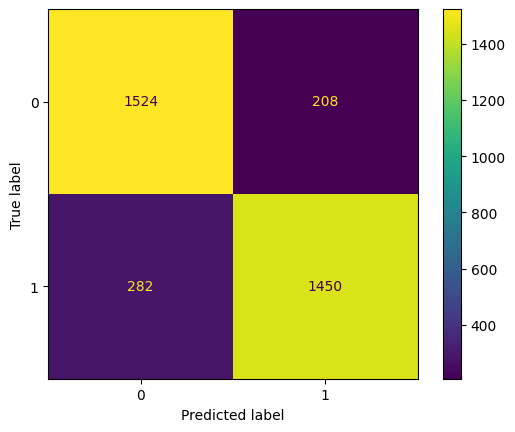

AUC Test: 0.9379708609571762
Gain from model: $43055


In [73]:
# Entrenamiento y evaluación de modelo con oversampling categórico (SMOTENC)
idx_cat_features = [model_df_nooh.columns.get_loc(col) for col in pairings_list]

# Oversampling
X_smotenc, y_smotenc = mod_prep.oversample_df(
    df=model_df_nooh,
    sampling_object=SMOTENC,
    random_state=0,
    categorical_features=idx_cat_features
)

# Train test model
results_smotenc = mod_prep.train_test_model(
    X=X_smotenc,
    y=y_smotenc,
    model_object=rf_model,
    test_size=0.2,
    random_state=0,
    stratify=y_smotenc
)

# Visualización de resultados
display(Markdown("# SMOTENC"))
mod_prep.print_model_results(results_smotenc)
cm_pred = results_smotenc["cm_pred"]
eco_score = mod_prep.economic_score(
    conf_matrix=cm_pred,
    avg_tkt=avg_tkt,
    churn_like=churn_like,
    churn_dislike=churn_dislike
    )
print("Gain from model: $", round(eco_score), sep="")

# SMOTE


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6926
           1       1.00      1.00      1.00      6926

    accuracy                           1.00     13852
   macro avg       1.00      1.00      1.00     13852
weighted avg       1.00      1.00      1.00     13852



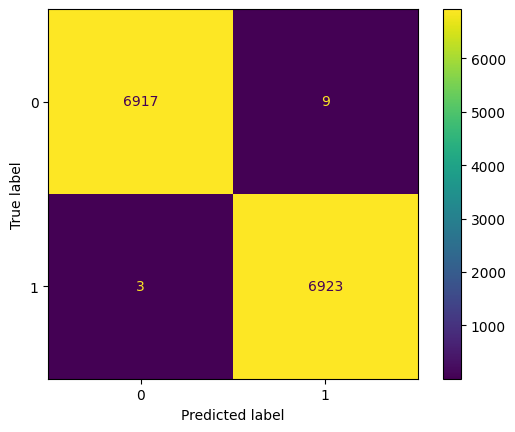

AUC Train: 0.9999967375086607

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

           0       0.86      0.89      0.88      1732
           1       0.89      0.86      0.87      1732

    accuracy                           0.87      3464
   macro avg       0.88      0.87      0.87      3464
weighted avg       0.88      0.87      0.87      3464



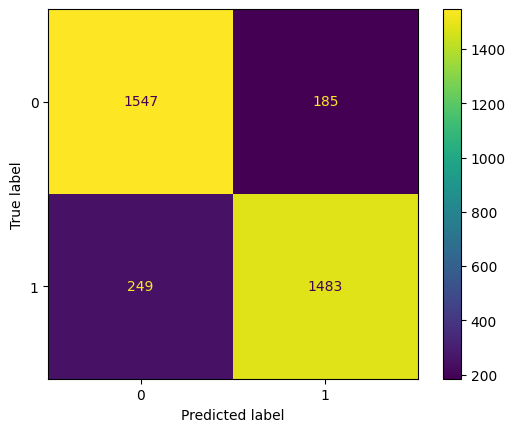

AUC Test: 0.9550675306284635
Gain from model: $45477


# ADASYN


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6850
           1       1.00      1.00      1.00      6926

    accuracy                           1.00     13776
   macro avg       1.00      1.00      1.00     13776
weighted avg       1.00      1.00      1.00     13776



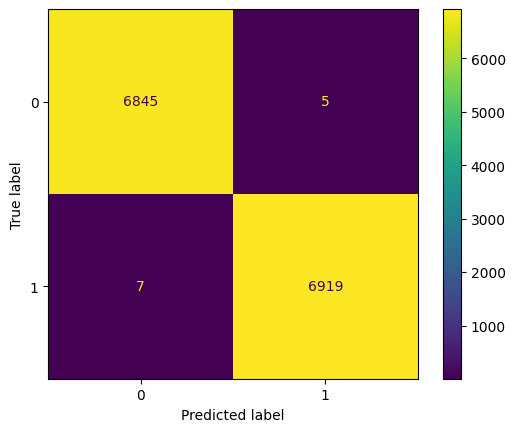

AUC Train: 0.999997481193261

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

           0       0.86      0.89      0.88      1712
           1       0.89      0.86      0.87      1732

    accuracy                           0.87      3444
   macro avg       0.87      0.87      0.87      3444
weighted avg       0.88      0.87      0.87      3444



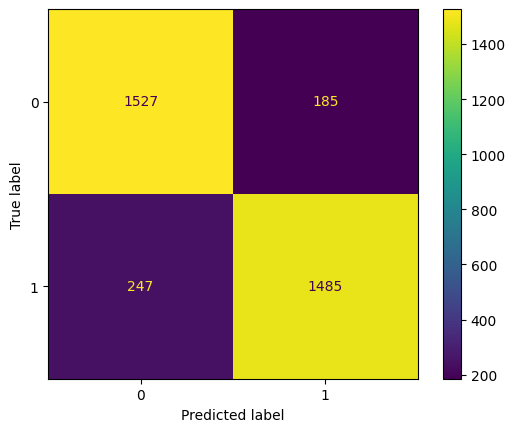

AUC Test: 0.9486023464311152
Gain from model: $45331


# BorderlineSMOTE


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6926
           1       1.00      1.00      1.00      6926

    accuracy                           1.00     13852
   macro avg       1.00      1.00      1.00     13852
weighted avg       1.00      1.00      1.00     13852



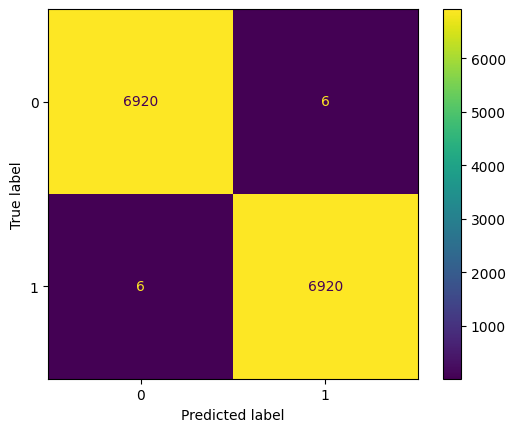

AUC Train: 0.9999963622700403

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1732
           1       0.89      0.87      0.88      1732

    accuracy                           0.88      3464
   macro avg       0.88      0.88      0.88      3464
weighted avg       0.88      0.88      0.88      3464



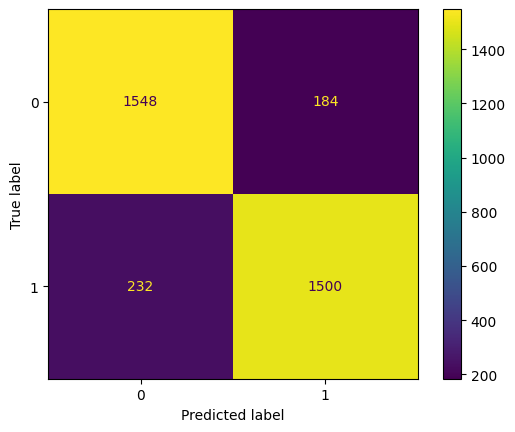

AUC Test: 0.9527637288054233
Gain from model: $46060


# SVMSMOTE


----------------------------------------------------

Train Metrics:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6926
           1       1.00      1.00      1.00      6926

    accuracy                           1.00     13852
   macro avg       1.00      1.00      1.00     13852
weighted avg       1.00      1.00      1.00     13852



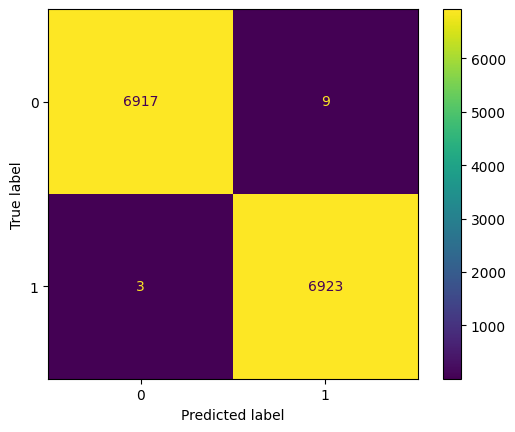

AUC Train: 0.9999948404689682

----------------------------------------------------

Test Metrics:

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1732
           1       0.90      0.86      0.88      1732

    accuracy                           0.88      3464
   macro avg       0.88      0.88      0.88      3464
weighted avg       0.88      0.88      0.88      3464



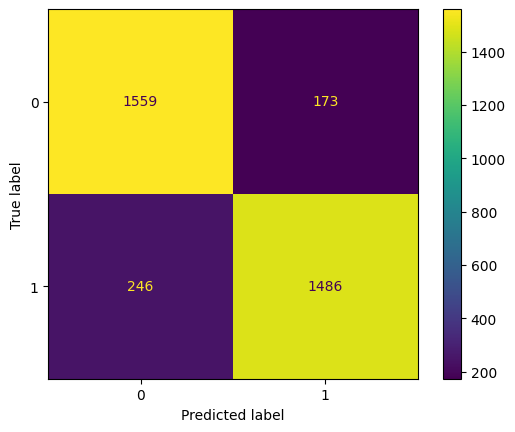

AUC Test: 0.9534904381057023
Gain from model: $46300


In [74]:
# Entrenamiento y evaluación de modelo con oversampling no categórico
sampling_objects = [SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE]

for obj in sampling_objects:
    # Oversampling
    X_resampled, y_resampled = mod_prep.oversample_df(
        df=model_df_nocat,
        sampling_object=obj,
        random_state=0,
    )
    # Train Test Model
    results_resampled = mod_prep.train_test_model(
        X=X_resampled,
        y=y_resampled,
        model_object=RandomForestClassifier(),
        test_size=0.2,
        random_state=0,
        stratify=y_resampled
    )
    # Visualización de resultados
    display(Markdown(f"# {obj.__name__}"))
    mod_prep.print_model_results(results_resampled)
    cm_pred = results_resampled["cm_pred"]
    eco_score = mod_prep.economic_score(
        conf_matrix=cm_pred,
        avg_tkt=avg_tkt,
        churn_like=churn_like,
        churn_dislike=churn_dislike
        )
    print("Gain from model: $", round(eco_score), sep="")

In [75]:
# Entropía luego de oversample
calc_entropy(y_resampled)

np.float64(1.0)

## Finetunning

In [76]:
# Oversampling de clase minoritaria
X_resampled, y_resampled = mod_prep.oversample_df(
    df=model_df_nocat,
    sampling_object=SMOTE,
    random_state=0
)

# Split en train, validation y test
X_train, X_val, X_test, y_train, y_val, y_test = mod_prep.train_test_val_split(
    X_resampled,
    y_resampled,
    val_size=0.2,
    test_size=0.2,
    random_state=0,
    stratify=y_resampled
)

# Definición de parámetros a testear
params_values = {
    #"n_estimators": range(100,550,50),
    #"criterion": ["gini", "entropy", "log_loss"],
    "max_depth": range(6,21),
    #"min_samples_split": range(2, 11),
    #"min_samples_leaf": range(2, 11),
    #"max_features": [None, "sqrt", "log2", 10, 5, 2]
}

# Creación de diccionario con valores para score económico
eco_score_dict = {
    "avg_tkt": avg_tkt,
    "churn_like": churn_like,
    "churn_dislike": churn_dislike
}

# Definición del modelo base
rf_base_model = RandomForestClassifier(
    n_estimators=300,
    criterion="gini",
    max_depth=9,
    min_samples_split=6,
    min_samples_leaf=5,
    max_features=10
)

# Ploteo de curvas de aprendizaje
mod_prep.plot_learning_curves(
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    base_model=rf_base_model,
    params_dict=params_values,
    eco_score_dict=eco_score_dict)

AttributeError: module 'src.utils.model_prep_eval' has no attribute 'plot_learning_curves'

## Evaluación del modelo

In [ ]:
model_df_nocat.columns.to_list()

In [ ]:
# Oversampling de clase minoritaria
X_resampled, y_resampled = mod_prep.oversample_df(
    df=model_df_nocat,
    sampling_object=SMOTE,
    random_state=0
)

# Creación del modelo
rf_tunned_model = RandomForestClassifier(
    n_estimators=300,
    criterion="gini",
    max_depth=9,
    min_samples_split=6,
    min_samples_leaf=5,
    max_features=10
)

model_eval = mod_prep.train_val_test_model(
    X=X_resampled,
    y=y_resampled,
    model_object=rf_tunned_model,
    val_size=0.2,
    test_size=0.2,
    random_state=0,
    stratify=y_resampled
)

print("Train:\n", model_eval["train_report"], "\nVal:\n", model_eval["val_report"])

Train:
               precision    recall  f1-score   support

         0.0       0.89      0.85      0.87      3170
         1.0       0.86      0.90      0.88      3170

    accuracy                           0.87      6340
   macro avg       0.87      0.87      0.87      6340
weighted avg       0.87      0.87      0.87      6340
 
Val:
               precision    recall  f1-score   support

         0.0       0.82      0.75      0.78      1057
         1.0       0.77      0.83      0.80      1057

    accuracy                           0.79      2114
   macro avg       0.79      0.79      0.79      2114
weighted avg       0.79      0.79      0.79      2114



In [ ]:
model = RandomForestClassifier()

cv = StratifiedKFold(n_splits=5, shuffle=True)
scores = cross_validate(model, X_resampled, y_resampled, scoring=["roc_auc", "precision", "accuracy"])
scores

{'fit_time': array([3.3463769 , 2.37644553, 2.72250271, 3.12122774, 2.74699855]),
 'score_time': array([0.0747261 , 0.06561971, 0.07566094, 0.12795544, 0.07483864]),
 'test_roc_auc': array([0.57120973, 0.33811308, 0.81105689, 0.82832658, 0.78880022]),
 'test_precision': array([0.56093489, 0.1799308 , 0.92198582, 0.95061728, 0.90497738]),
 'test_accuracy': array([0.56906339, 0.41248817, 0.61258278, 0.63795551, 0.58495031])}

In [ ]:
print("AUC promedio:", scores['test_roc_auc'].mean())
print("AUC desvío:", scores['test_roc_auc'].std())
print("AUC Coef Var:", scores['test_roc_auc'].std()/scores['test_roc_auc'].mean())

AUC promedio: 0.6675013006107507
AUC desvío: 0.18918513310022878
AUC Coef Var: 0.28342286813093553


# TODO: